<a href="https://colab.research.google.com/github/ds-20195/notebooks/blob/main/Notebook4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%config InlineBackend.figure_formats = ["retina"]

# Data and the State (DATA 20195/30195)

# Lab 4: Migration and relocation

In this notebook we get our hands on some data about who moves where.

In [ ]:
!pip install -q geopandas networkx us "census>=0.8.27" xlrd
!pip install -q "git+https://github.com/ds-20195/notebooks#egg=ds20195&subdirectory=lib"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 2.8 MB/s eta 0:00:00


In [ ]:
# FILL THIS IN WITH YOUR OWN CENSUS API KEY. You can get one for free at https://api.census.gov/data/key_signup.html
api_key = "fakecode"

In [4]:
import json

import geopandas as gpd
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import requests
import us

from census import Census
from shapely.geometry import Point

from ds20195 import google_sheets_credentials, generate_flow_sheet

In [ ]:
census = Census(key=api_key, year=2020)

In [ ]:
# @markdown This code cell checks that the census API is working
try:
    _ = census.pl.get(
        ("NAME",),
        geo={"for": "state:17"}
    )
    print("The Census API appears to be working!")
except Exception:
    raise RuntimeError(
        "Error fetching data from the Census API. Check your API key or switch to using the backup data. "
    )


The Census API appears to be working!


In [8]:
# @markdown This code cell contains a helper function for our backup data. Feel free to ignore.
import gzip
import io
def load_json_gzip_url(url, timeout=60):
    with requests.get(url, stream=True, timeout=timeout) as resp:
        resp.raise_for_status()
        with gzip.GzipFile(fileobj=resp.raw) as gz:
            with io.TextIOWrapper(gz, encoding="utf-8") as f:
                return json.load(f)

## ACS migration flows

In addition to standard demographic data, the ACS also collects information on residential mobility; in particular the survey asks respondents where they lived one year prior to the survey. We will use this data to construct county-to-county migration flow diagrams.

Note that the ACS publishes these as *average annual flow* estimates derived from the 5-year survey window, not as 5-year totals.

Data sourced from the "Net Gross US" document at [https://www.census.gov/data/tables/2020/demo/geographic-mobility/county-to-county-migration-2016-2020.html](https://www.census.gov/data/tables/2020/demo/geographic-mobility/county-to-county-migration-2016-2020.html)

In [9]:
# @markdown This cell makes a request against the Census API and then stores
# @markdown the output data in a list called `raw_flows`

# The census package is not useful here, so we will just construct the request ourselves
try:
  import urllib3
  urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

  response = requests.get(
    "https://www2.census.gov/programs-surveys/demo/tables/geographic-mobility/2020/county-to-county-migration-2016-2020/county-to-county-migration-flows/Net_Gross_US.txt",
    verify=False,
  )

  # Check that the response succeeded
  if response.status_code != 200:
    raise RuntimeError(
        "Could not retrieve data from the Census API. "
    )

  # Deal with the text encoding.
  decoded_response = response.content.decode("latin1")

  # Split the text on a new line character and store in list
  raw_flows = decoded_response.split("\n")

except Exception:
  raw_flows = load_json_gzip_url("https://github.com/ds-20195/notebooks/raw/refs/heads/main/notebook_data/notebook4_raw_flows.json.gz")

Let's take a look at the first few items in the `raw_flows` list.

In [10]:
for i in range(3):
  print(raw_flows[i])

001001001003 Alabama                       Autauga County                      Alabama                       Baldwin County                            30       37      489      395     -459      396      519      398 
001001001005 Alabama                       Autauga County                      Alabama                       Barbour County                             5        8        0       23        5        8        5        8 
001001001007 Alabama                       Autauga County                      Alabama                       Bibb County                               12       18       48       61      -36       62       60       65 


Notice that each row has a large amount of white space between the entries — text fields are left-aligned and number fields are right-aligned, so each column lives at a fixed character position.
This is called _fixed width column formatting_ and it is a common data distribution format for the Census.


In the case of migration flows, the Census also publishes [additional documentation](https://www.census.gov/topics/population/migration/guidance/county-to-county-migration-flows/2016-2020.html) that clarifies what position ranges represent. We are interested in the table on page 11 under the header **County/MCD-to-County/MCD Net and Gross Migration Files**.



| Field Description | Field Position |
|---|---|
| State/U.S. Island Area/Foreign Region Code of Geography A (FIPS) | 1–3 |
| FIPS County Code of Geography A | 4–6 |
| State/U.S. Island Area/Foreign Region Code of Geography B (FIPS) | 7–9 |
| FIPS County Code of Geography B | 10–12 |
| State/U.S. Island Area/Foreign Region Name of Geography A | 14–43 |
| County Name of Geography A | 44–78 |
| State/U.S. Island Area/Foreign Region Name of Geography B | 80–109 |
| County Name of Geography B | 110–144 |
| Flow from Geography B to Geography A – Estimate | 146–153 |
| Flow from Geography B to Geography A – MOE | 155–162 |
| Counterflow from Geography A to Geography B – Estimate | 164–171 |
| Counterflow from Geography A to Geography B – MOE | 173–180 |
| Net Migration from Geography B to Geography A – Estimate | 182–189 |
| Net Migration from Geography B to Geography A – MOE | 191–198 |
| Gross Migration between Geography A and Geography B – Estimate | 200–207 |
| Gross Migration between Geography A and Geography B – MOE | 209–216 |


> Note: MOE is an abbreviation for "Margin Of Error"

Parsing this data will involve 3 steps. First, we create more convenient short names for the columns.

In [11]:
place_columns = [
    "a_fips",
    "b_fips",
    "a_state",
    "a_county",
    "b_state",
    "b_county",
]

flow_columns = [
    "b_to_a_flow_est",
    "b_to_a_flow_moe",
    "a_to_b_flow_est",
    "a_to_b_flow_moe",
    "net_b_to_a_flow_est",
    "net_b_to_a_flow_moe",
    "gross_flow_est",
    "gross_flow_moe",
]

columns = place_columns + flow_columns

Then we create a `get_migration_value` helper function that will handle the slicing to the correct column width, and a `fips_is_numeric` helper function to filter out non-US localities.

In [12]:
# The table the Census publishes is 1-indexed so we need to adjust slice
# ranges carefully
col_to_slice = {
    "a_fips": (1,6), # Start at 1 to strip the leading 0 in the state fips
    "b_fips": (7,12), # Start at 7 to strip the leading 0 in the state fips
    "a_state": (13,43),
    "a_county": (43,78),
    "b_state": (79,109),
    "b_county": (109,144),
    "b_to_a_flow_est": (145,153),
    "b_to_a_flow_moe": (154,162),
    "a_to_b_flow_est": (163,171),
    "a_to_b_flow_moe": (172,180),
    "net_b_to_a_flow_est": (181,189),
    "net_b_to_a_flow_moe": (190,198),
    "gross_flow_est": (199,207),
    "gross_flow_moe": (208,216),
}

def get_migration_value(item_name, input_string):
    start_slice, end_slice = col_to_slice[item_name]
    return input_string[start_slice:end_slice].strip() # .strip() removes surrounding whitespace

# We need to filter out non-US localities. The ACS data includes migration
# from places like South America (fips code "SAM") that aren't all-numeric.
def fips_is_numeric(fips_code):
    return fips_code.isdigit()

Now we iterate through each row, and construct a data dictionary containing the entries for each of the place and flow columns. These dictionaries are then consolidated into a Pandas DataFrame.

Since the migration flow is uniquely determined by the pair (starting county, ending county), we will also create a _MultiIndex_ on the dataframe that makes it easier to handle as a pair.

In [13]:
# Go through each line of raw text. If the line isn't blank, build a
# dictionary mapping each column name to its value from that line.
flow_df_data = []
for raw_flow_string in raw_flows:
    if not raw_flow_string.strip():
        continue
    data_dict = {}
    for col in columns:
        data_dict[col] = get_migration_value(col, raw_flow_string)

    if fips_is_numeric(data_dict["a_fips"]) and fips_is_numeric(data_dict["b_fips"]):
        flow_df_data.append(data_dict)

# Create a new multi-index using ('a_fips','b_fips') pairs
flow_df = pd.DataFrame(flow_df_data).set_index(["a_fips", "b_fips"])

for col in flow_columns:
    flow_df[col] = flow_df[col].astype(int)

flow_df["net_a_to_b_flow_est"] = -flow_df["net_b_to_a_flow_est"]
flow_df["net_a_to_b_flow_moe"] = flow_df["net_b_to_a_flow_moe"]

In [14]:
flow_df

a_state         a_county      b_state  \
a_fips b_fips                                              
01001  01003       Alabama   Autauga County      Alabama   
       01005       Alabama   Autauga County      Alabama   
       01007       Alabama   Autauga County      Alabama   
       01015       Alabama   Autauga County      Alabama   
       01017       Alabama   Autauga County      Alabama   
...                    ...              ...          ...   
72153  72125   Puerto Rico  Yauco Municipio  Puerto Rico   
       72127   Puerto Rico  Yauco Municipio  Puerto Rico   
       72135   Puerto Rico  Yauco Municipio  Puerto Rico   
       72145   Puerto Rico  Yauco Municipio  Puerto Rico   
       72151   Puerto Rico  Yauco Municipio  Puerto Rico   

                           b_county  b_to_a_flow_est  b_to_a_flow_moe  \
a_fips b_fips                                                           
01001  01003         Baldwin County               30               37   
       01005         Barbour County                5                8   
       01007            Bibb County               12               18   
       01015         Calhoun County                2                4   
       01017        Chambers County                0               29   
...                             ...              ...              ...   
72153  72125   San Germán Municipio                0               30   
       72127     San Juan Municipio               26               43   
       72135     Toa Alta Municipio                0               30   
       72145    Vega Baja Municipio                3                8   
       72151      Yabucoa Municipio               74              114   

               a_to_b_flow_est  a_to_b_flow_moe  net_b_to_a_flow_est  \
a_fips b_fips                                                          
01001  01003               489              395                 -459   
       01005                 0               23                    5   
       01007                48               61                  -36   
       01015                23               32                  -21   
       01017                 7               16                   -7   
...                        ...              ...                  ...   
72153  72125                11               21                  -11   
       72127                40               64                  -14   
       72135                 1                3                   -1   
       72145                 0               34                    3   
       72151                 0               30                   74   

               net_b_to_a_flow_moe  gross_flow_est  gross_flow_moe  \
a_fips b_fips                                                        
01001  01003                   396             519             398   
       01005                     8               5               8   
       01007                    62              60              65   
       01015                    34              25              31   
       01017                    16               7              16   
...                            ...             ...             ...   
72153  72125                    21              11              21   
       72127                    76              66              77   
       72135                     3               1               3   
       72145                     8               3               8   
       72151                   114              74             114   

               net_a_to_b_flow_est  net_a_to_b_flow_moe  
a_fips b_fips                                            
01001  01003                   459                  396  
       01005                    -5                    8  
       01007                    36                   62  
       01015                    21                   34  
       01017                     7                   16  
...                            ...

The output display of `flow_df` should now have two index columns on the left — `a_fips` and `b_fips` — the start point and end point. So the usual `.loc[<index>]` semantics still work, but `<index>` will take the form of an ordered pair.

In [15]:
flow_df.loc[('01001', '01003')]

,01001
,01003
a_state,Alabama
a_county,Autauga County
b_state,Alabama
b_county,Baldwin County
b_to_a_flow_est,30
b_to_a_flow_moe,37
a_to_b_flow_est,489
a_to_b_flow_moe,395
net_b_to_a_flow_est,-459


### TASK: Migration to Cook County

Determine approximately how many people migrated to Cook County between 2016 and 2020.  (Cook County's FIPS code is `17031`.)



In [16]:
# YOUR CODE HERE

# Don't forget to ask for help if you get stuck!

### Migration Between NYC Boroughs

With the ACS migration data, we can now answer some more interesting questions. For example, how do people move between the 5 boroughs of New York City?

In [17]:
nyc_county_fips_codes = {
    "The Bronx": "36005",      # Bronx County
    "Brooklyn": "36047",       # Kings County
    "Manhattan": "36061",      # New York County
    "Queens": "36081",         # Queens County
    "Staten Island": "36085",  # Richmond County
}

In [18]:
county_to_county_fips_pairs = []
nyc_county_fips_list = list(nyc_county_fips_codes.values())
for fips1 in nyc_county_fips_list:
    for fips2 in nyc_county_fips_list:
        if fips1 != fips2:
            county_to_county_fips_pairs.append((fips1, fips2))

flow_df.loc[county_to_county_fips_pairs]

a_state         a_county   b_state         b_county  \
a_fips b_fips                                                         
36005  36047   New York     Bronx County  New York     Kings County   
       36061   New York     Bronx County  New York  New York County   
       36081   New York     Bronx County  New York    Queens County   
       36085   New York     Bronx County  New York  Richmond County   
36047  36005   New York     Kings County  New York     Bronx County   
       36061   New York     Kings County  New York  New York County   
       36081   New York     Kings County  New York    Queens County   
       36085   New York     Kings County  New York  Richmond County   
36061  36005   New York  New York County  New York     Bronx County   
       36047   New York  New York County  New York     Kings County   
       36081   New York  New York County  New York    Queens County   
       36085   New York  New York County  New York  Richmond County   
36081  36005   New York    Queens County  New York     Bronx County   
       36047   New York    Queens County  New York     Kings County   
       36061   New York    Queens County  New York  New York County   
       36085   New York    Queens County  New York  Richmond County   
36085  36005   New York  Richmond County  New York     Bronx County   
       36047   New York  Richmond County  New York     Kings County   
       36061   New York  Richmond County  New York  New York County   
       36081   New York  Richmond County  New York    Queens County   

               b_to_a_flow_est  b_to_a_flow_moe  a_to_b_flow_est  \
a_fips b_fips                                                      
36005  36047              6924              969             4040   
       36061             11469             1191             4965   
       36081              5242              978             3701   
       36085               461              183              267   
36047  36005              4040              716             6924   
       36061             21743             1419            12241   
       36081              8942              889            14949   
       36085              1038              254             6065   
36061  36005              4965              883            11469   
       36047             12241             1085            21743   
       36081              5938              795             8427   
       36085               427              141              560   
36081  36005              3701              628             5242   
       36047             14949             1381             8942   
       36061              8427             1066             5938   
       36085               791              240              859   
36085  36005               267              166              461   
       36047              6065             1014             1038   
       36061               560              248              427   
       36081               859              277              791   

               a_to_b_flow_moe  net_b_to_a_flow_est  net_b_to_a_flow_moe  \
a_fips b_fips                                                              
36005  36047               716                 2884                 1269   
       36061               883                 6504                 1490   
       36081               628                 1541                 1108   
       36085               166                  194                  260   
36047  36005               969                -2884                 1269   
       36061              1085                 9502                 1912   
       36081              1381                -6007                 1752   
       36085              1014                -5027                 1029   
36061  36005              1191                -6504                 1490   
       36047              1419                -9502                 1912   
       36081              1066              

#### Interlude: NetworkX

As discussed in lecture, we'll use the Python library called NetworkX as our main option to store graphs.

The following two code cells demonstrate the basic NetworkX workflow we will use:
1. Create an empty graph.
2. Add edges and nodes.
3. Display the graph with `nx.draw` or `nx.draw_networkx_edges`.

Re-run the following cells a few times and you'll see that the picture (the embedding) varies.

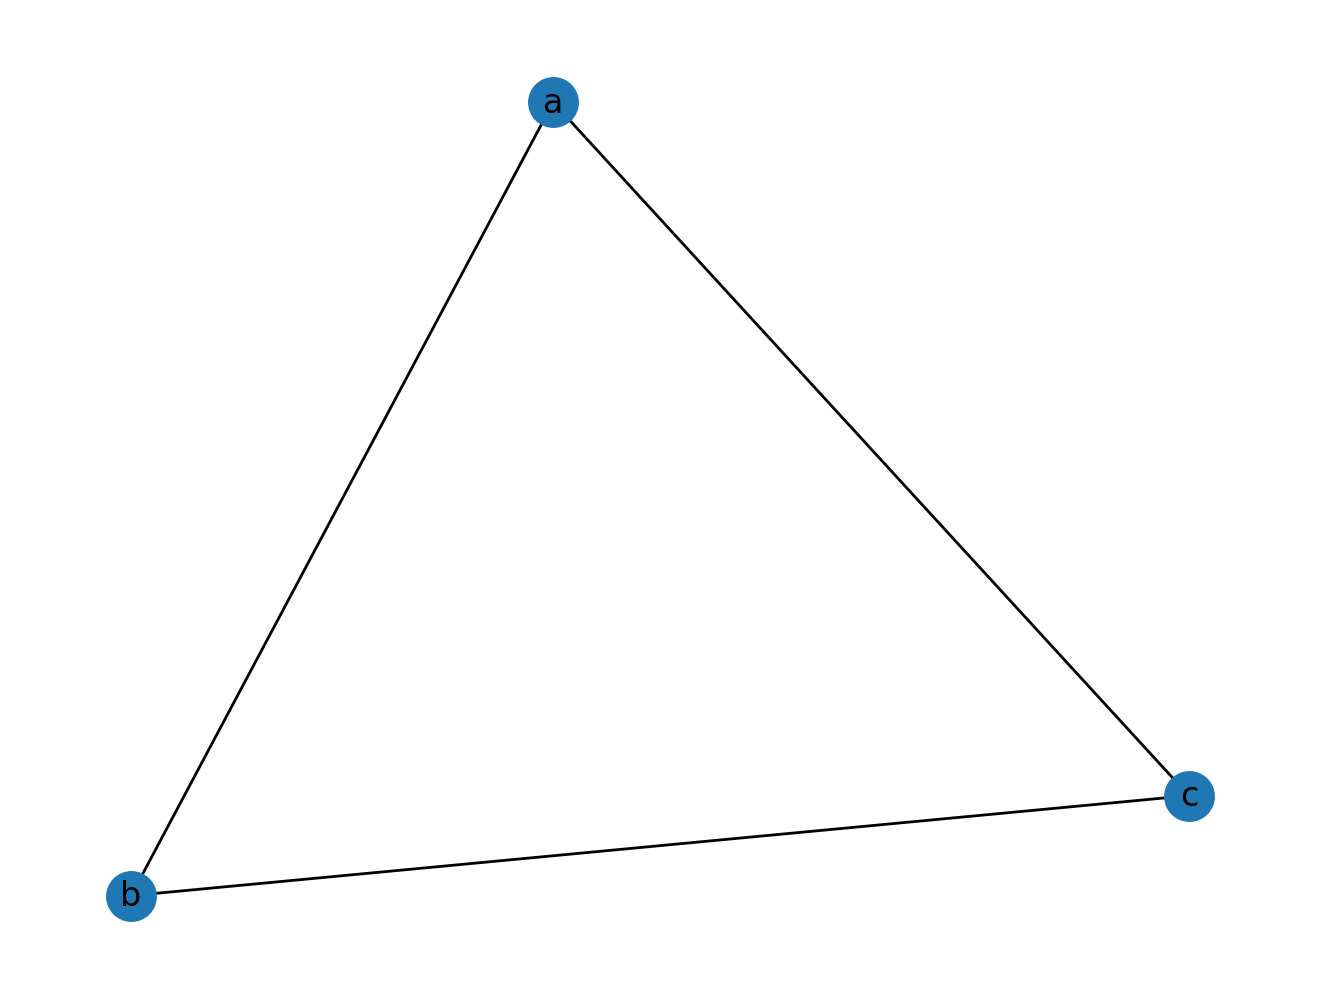

In [19]:
import networkx as nx # 'nx' is a common shortening of 'networkx'

graph1 = nx.Graph() # an undirected graph
graph1.add_edge("a", "b")
graph1.add_edge("a", "c")
graph1.add_edge("b", "c")

nx.draw(graph1, with_labels=True)

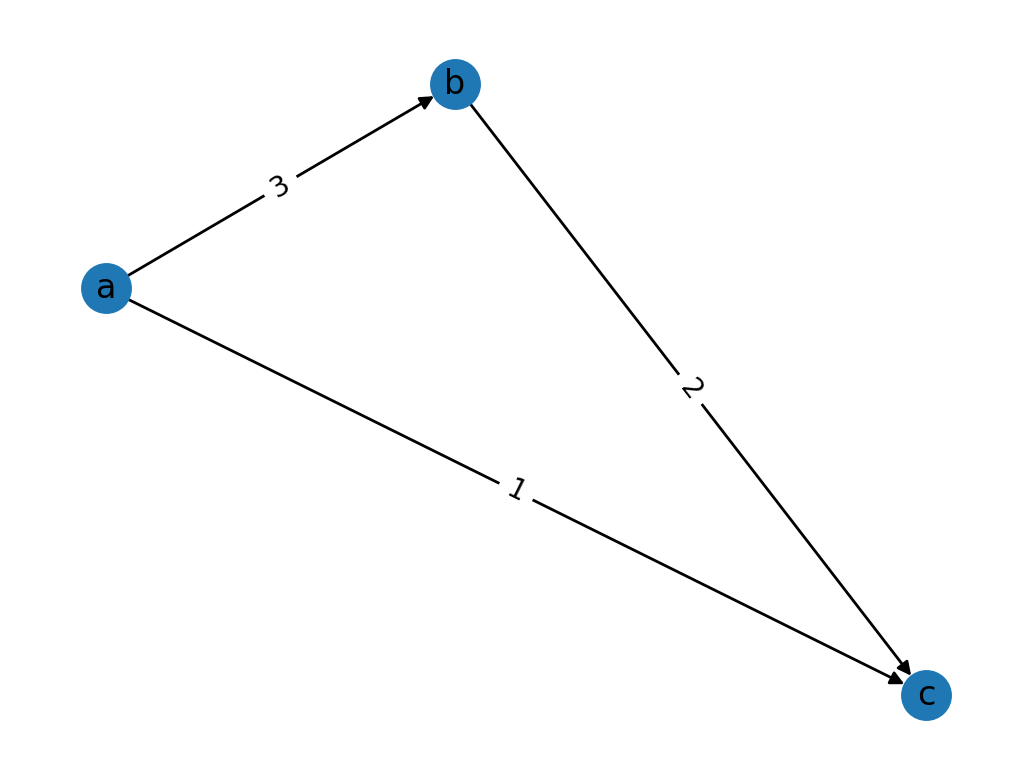

In [20]:
graph2 = nx.DiGraph()
graph2.add_edge("a", "b", weight=3)
graph2.add_edge("a", "c", weight=1)
graph2.add_edge("b", "c", weight=2)

fig, ax = plt.subplots()
pos = nx.spring_layout(graph2)
nx.draw(graph2, pos, ax=ax, with_labels=True)
nx.draw_networkx_edge_labels(graph2, pos, edge_labels=nx.get_edge_attributes(graph2, "weight"), ax=ax)
plt.show()

Let's take a look at the way the graph adjacency data is stored.

In [21]:
dict(graph2.adjacency())

{'a': {'b': {'weight': 3}, 'c': {'weight': 1}},
 'b': {'c': {'weight': 2}},
 'c': {}}

### TASK: Make a graph

Create any graph with four nodes and 5 edges, one of which is a self-loop. Name the nodes W,X,Y,Z.

In [22]:
# YOUR CODE HERE

# Don't forget to ask for help if you get stuck!

Back to NYC boroughs. We will now construct a GeoDataFrame of the 5 boroughs, and then plot the county-to-county flows on top of the plot of the GeoDataFrame using NetworkX.

First, let's construct a net migration graph.

> Syntax Note: `for key, value in dictionary.items()` is a convenient way to iterate over (key,value) pairs in Python.

In [23]:
net_migration_graph = nx.DiGraph()

for a_county, a_county_fips in nyc_county_fips_codes.items():
    for b_county, b_county_fips in nyc_county_fips_codes.items():
        if a_county == b_county:
            continue

        net_flow = flow_df.loc[(a_county_fips, b_county_fips), "net_a_to_b_flow_est"]
        if net_flow > 0:
            net_migration_graph.add_edge(
                a_county,
                b_county,
                weight=net_flow,
            )

In [24]:
# @markdown This cell retrieves the official US-wide county geodataframe and
# @markdown filters it to the NYC boroughs which is then stored in `nyc_county_gdf`

try:
  county_gdf = gpd.read_file("https://www2.census.gov/geo/tiger/TIGER2020/COUNTY/tl_2020_us_county.zip").set_index("GEOID").to_crs("EPSG:9311")
except Exception:
  url = "https://raw.githubusercontent.com/ds-20195/notebooks/main/notebook_data/notebook4_county_gdf.parquet"
  resp = requests.get(url, timeout=120)
  resp.raise_for_status()
  county_gdf = gpd.read_parquet(io.BytesIO(resp.content))

nyc_county_gdf = county_gdf.loc[nyc_county_fips_codes.values()]


This next bit is a technical step. The `nx.draw` and `nx.draw_networkx_edges` functions accept a `pos` parameter which determines the position of each of the nodes of the graph. GeoPandas uses a library called Shapely under the hood to handle the drawing of its geometry objects, so to combine our NetworkX graph with the plot from the county GeoDataFrame, we may need to go back and forth between the coordinates of the NetworkX nodes and Shapely `Point` objects.

To go from a point to coordinates, we'll use a helper function called  `cast_point`.  

In [25]:
def cast_point(p):
    return (p.x, p.y)

Now, plot it!  We suppress the axes (because those aren't helpful here) and choose some plotting details, then draw the shapes, points, and arrows for flows.

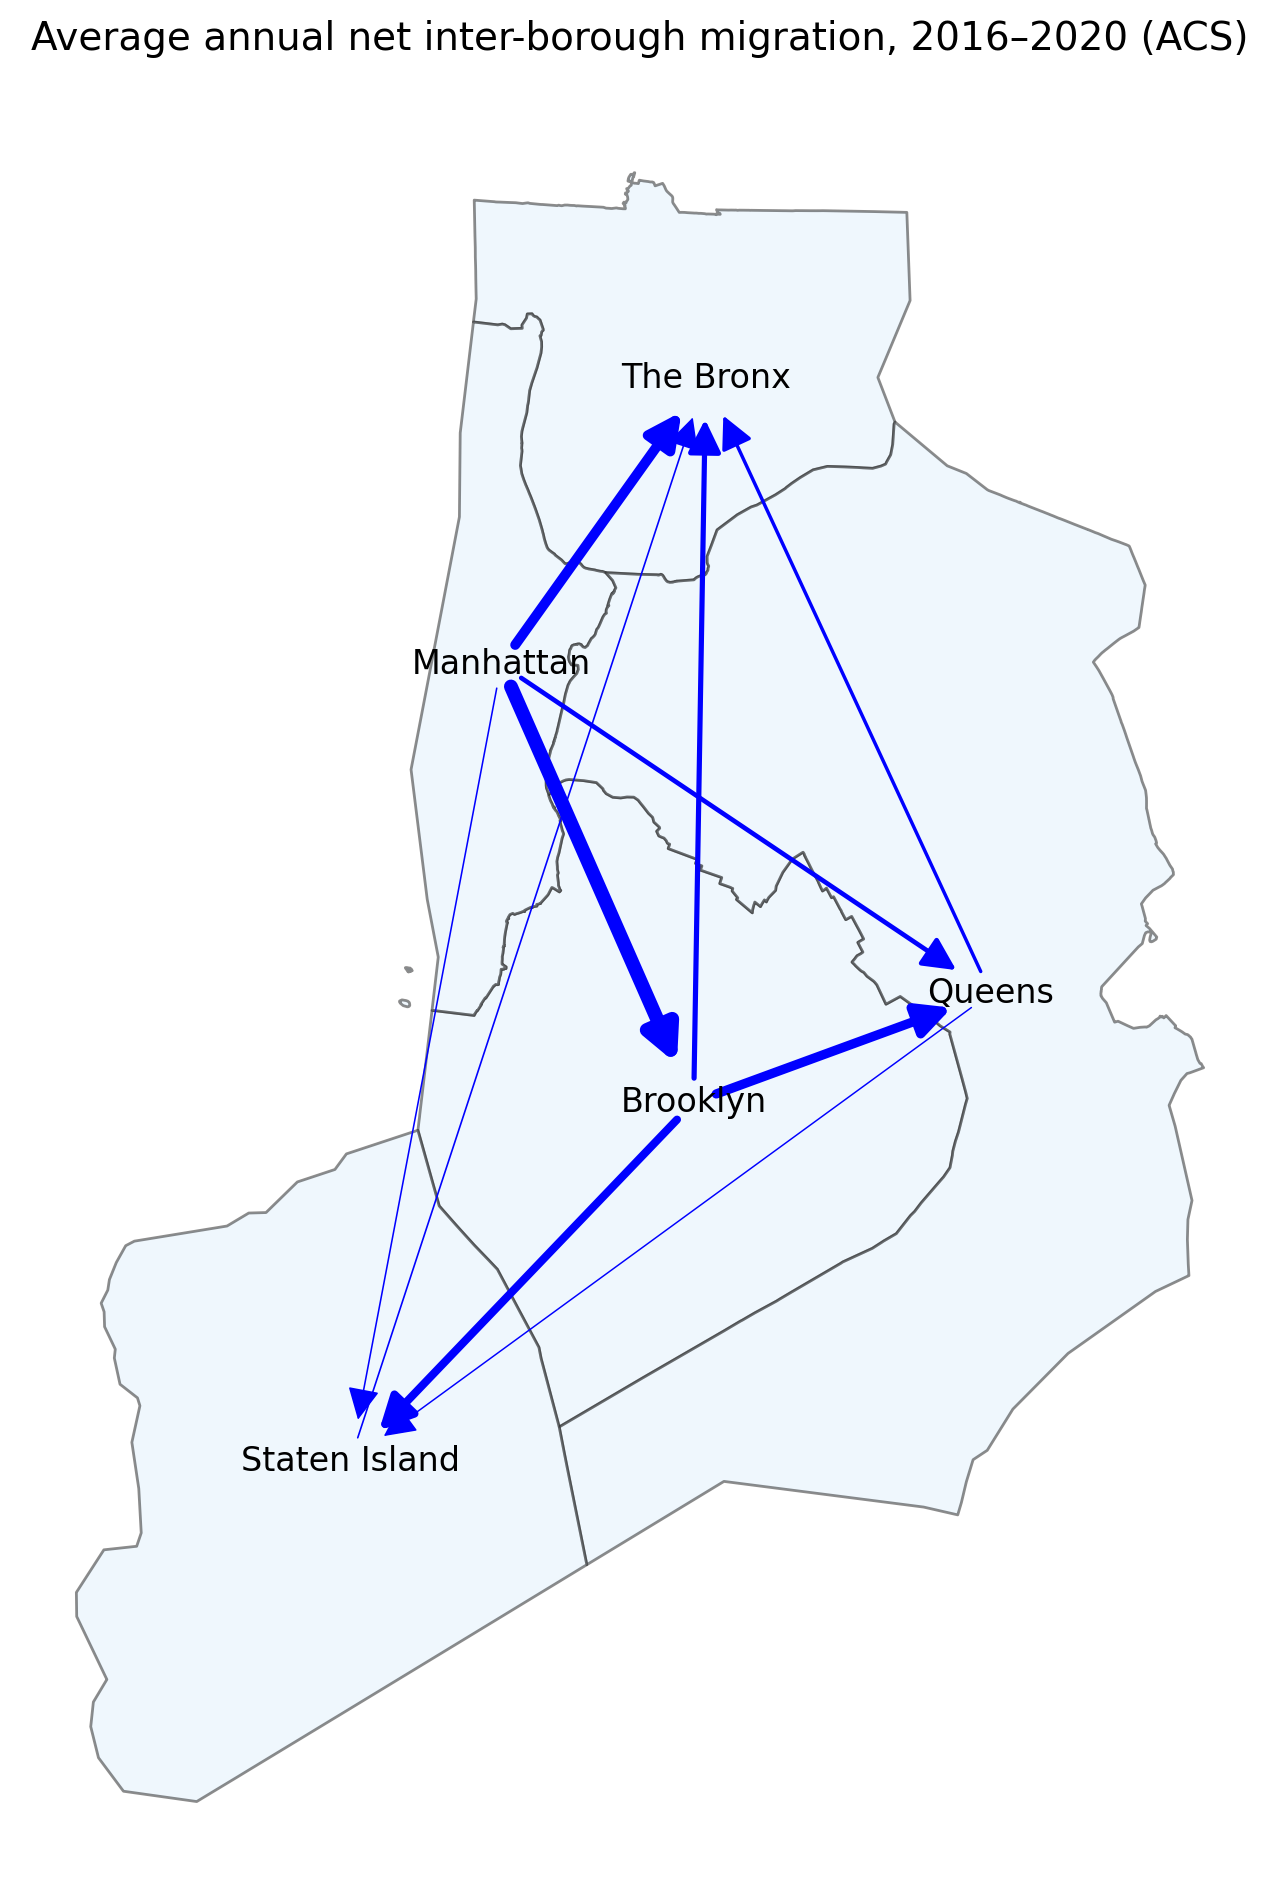

In [26]:
fig, ax = plt.subplots(figsize=(8, 16))
ax.axis("off")
ax.set_title("Average annual net inter-borough migration, 2016–2020 (ACS)", fontsize=14, pad=15)
nyc_county_gdf.plot(ax=ax, edgecolor="0.1", linewidth=1, color="#e1f1fd", alpha=0.5)

position_dict = {}
for borough, county_fips in nyc_county_fips_codes.items():
    position_dict[borough] = cast_point(nyc_county_gdf.loc[county_fips].geometry.representative_point())

nx.draw_networkx_labels(net_migration_graph, position_dict, ax=ax)

max_weight = max([w for _, _, w in net_migration_graph.edges(data='weight')],default=1)

for edge in net_migration_graph.edges(data='weight'):
    nx.draw_networkx_edges(
        net_migration_graph,
        position_dict,
        edgelist=[edge],
        width=0.5 + 4.5 * edge[2] / max_weight,
        ax=ax,
        edge_color="blue",
        arrowsize=25,
        arrowstyle='-|>',
        min_target_margin=15,
    )

### DISCUSSION: Net or both ways?

We chose the "net" graph – though the estimated flows go both ways, we took the difference and plotted only one arrow.  How might you go about conceptualizing the viz for showing BOTH flows?  Why might you prefer one or the other?

## Migration with PUMS data

OK, so there's only so much we can do with the ACS data, which really is just numbers of people moving from one county to another.  If we want to drill down into race or other attributes, we should switch over to PUMS, or the "Public Use Microdata Sample."  Let's pull in something called `rac1p` that records the correspondence between numerical codes found in the PUMS data and familiar race categories.

Important: PUMS is an extraordinary data source because since it's leveraging all the microdata, it lets you drill down way past these categories. Check out the [API docs](https://api.census.gov/data/2023/acs/acs1/pums/variables.html) for all the codes.  [RAC2P](https://api.census.gov/data/2023/acs/acs1/pums/variables/RAC2P.json) and [RAC3P](https://api.census.gov/data/2023/acs/acs1/pums/variables/RAC3P.json) are much more granular. But we're keeping it simple for now.

In [27]:
pums_code_to_race_category = {
    "1": "white",  # White alone
    "2": "black",  # Black or African American alone
    "3": "amin",   # "American Indian alone",
    "4": "amin",   # Alaska Native alone
    "5": "amin",   # "American Indian and Alaska Native tribes specified; or American Indian or Alaska Native, not specified and no other races",
    "6": "aapi",   # "Asian alone",
    "7": "aapi",   # "Native Hawaiian and Other Pacific Islander alone",
    "8": "other",  # "Some other race alone",
    "9": "two_or_more",  # "Two or More Races"
}

This next one populates the gdf with all the national data.  

Recall that the geographical units for PUMS data are called [PUMAs](https://www.census.gov/programs-surveys/geography/guidance/geo-areas/pumas.html), or Public Use Microdata Areas.  

In [28]:
# @markdown This cell makes a request using the Census API
# @markdown for the ACS. We retrieve all of the 1-year
# @markdown migration data for the year 2023 for all states
# @markdown in the US, and we retrieve the corresponding
# @markdown PUMA shapefile. Migration data is stored in
# @markdown `pums_results` and the shapefile data is
# @markdown stored in `pumas_gdf`.


url = "https://github.com/ds-20195/notebooks/raw/refs/heads/main/notebook_data/notebook4_pumas_gdf.parquet"

resp = requests.get(url, timeout=120)
resp.raise_for_status()

pumas_gdf = gpd.read_parquet(io.BytesIO(resp.content))
pums_results = load_json_gzip_url("https://github.com/ds-20195/notebooks/raw/refs/heads/main/notebook_data/notebook4_pums_results.json.gz")

# The code below can take forever to execute depending on the state of
# the Census servers, so we use some pre-loaded data.

# ==========================================================================
# == Uncomment and modify the code below if you want other PUMS variables ==
# ==========================================================================

# pums_results = []
# puma_gdfs = []

# session = requests.Session()

# for state in us.states.STATES:

#     dataset = "pumspr" if state.fips == "72" else "pums"
#     pums_results_filename = f"{state.fips}_pums_results.json"

#     print(f"Retrieving PUMS data for {state.name}")
#     resp = session.get(
#         f"https://api.census.gov/data/2023/acs/acs1/{dataset}",
#         params={
#             "get": "MIGSP,MIGPUMA,RAC1P",
#             "for": "public use microdata area:*",
#             "in": f"state:{state.fips}",
#         },
#         timeout=360,
#     )

#     if not resp.ok:
#         print(f"Request failed for {state.name}: {resp.status_code}")
#         print(resp.text[:500])
#         raise RuntimeError(f"Failed to retrieve PUMS data for {state.name}")

#     try:
#         state_pums_response = resp.json()
#     except requests.JSONDecodeError:
#         print(f"Non-JSON response for {state.name}")
#         print(resp.text[:500])
#         raise RuntimeError(f"Failed to retrieve PUMS data for {state.name}")

#     pums_results += state_pums_response[1:]

#     gdf_filename = f"tl_2024_{state.fips}_puma20.zip"
#     gdf_url = f"https://www2.census.gov/geo/tiger/TIGER2024/PUMA20/{gdf_filename}"

#     print(f"Retrieving PUMA shapefile for {state.name}")
#     puma_gdfs.append(gpd.read_file(gdf_url))
# pumas_gdf = gpd.GeoDataFrame(pd.concat(puma_gdfs), crs=puma_gdfs[0].crs).set_index("GEOID20")

# # Note that you could add in other variables from the PUMS data in the line above.  For instance, this alternative gets RAC3P as well as RAC1P.
# #
# #     resp = session.get(
# #         f"https://api.census.gov/data/2023/acs/acs1/{dataset}",
# #         params={
# #             "get": "MIGSP,MIGPUMA,RAC1P,RAC3P",
# #             "for": "public use microdata area:*",
# #             "in": f"state:{state.fips}",
# #         },
# #         timeout=360,
# #     )

In [29]:
pumas_gdf

,STATEFP20,PUMACE20,GEOIDFQ20,NAMELSAD20,MTFCC20,FUNCSTAT20,ALAND20,AWATER20,INTPTLAT20,INTPTLON20,geometry
GEOID20,,,,,,,,,,,
0101700,01,01700,795P200US0101700,"Autauga, Dallas, Lowndes & Perry Counties PUMA",G6120,S,7793139137,98975711,+32.4058854,-086.9461896,"POLYGON ((-86.47447 32.32588, -86.47442 32.325..."
0100100,01,00100,795P200US0100100,"Lauderdale, Colbert & Franklin Counties PUMA",G6120,S,4907844113,245298908,+34.6961048,-087.7750128,"POLYGON ((-87.68871 35.00375, -87.68655 35.003..."
0100200,01,00200,795P200US0100200,Limestone County PUMA,G6120,S,1459195371,113412127,+34.8102387,-086.9813995,"POLYGON ((-86.9524 34.99413, -86.95174 34.9941..."
0101000,01,01000,795P200US0101000,"Cullman, Marion & Winston Counties PUMA",G6120,S,5413303393,104564546,+34.1280167,-087.3603043,"POLYGON ((-87.10991 34.2993, -87.10994 34.3014..."
0102400,01,02400,795P200US0102400,Coffee & Dale Counties PUMA,G6120,S,3211842092,7958530,+31.4168403,-085.8136506,"POLYGON ((-85.41743 31.31511, -85.41743 31.315..."
...,...,...,...,...,...,...,...,...,...,...,...
5600100,56,00100,795P200US5600100,"Sheridan, Park, Teton, Lincoln & Big Horn Coun...",G6120,S,53539040353,751668213,+43.9645802,-109.2980711,"POLYGON ((-108.91313 43.91415, -108.91313 43.9..."
5600200,56,00200,795P200US5600200,"Campbell, Goshen, Platte, Johnson, Washakie, W...",G6120,S,60555166724,205831246,+43.6518098,-105.4270533,"POLYGON ((-104.96945 42.60884, -104.96846 42.6..."
5600300,56,00300,795P200US5600300,Laramie County PUMA,G6120,S,6956355028,4348083,+41.2928302,-104.6603950,"POLYGON ((-104.77302 40.99983, -104.77394 40.9..."


Still building the geodataframe -- one thing to notice is that we're using "internal points" provided by the Census Bureau as the location of the node associated to each PUMA.  (See [Census Glossary](https://www.census.gov/programs-surveys/geography/about/glossary.html))  These show up as `INTPTLAT20` and `INTPTLON20`.

In [30]:
def row_to_point(row):
  return Point(float(row["INTPTLON20"]), float(row["INTPTLAT20"]))

puma_points_gdf = gpd.GeoDataFrame(
    {
        "geometry": pumas_gdf.apply(
            row_to_point,
            axis=1,
        ),
        "name": pumas_gdf["NAMELSAD20"],
        "lat": pumas_gdf["INTPTLAT20"].astype(float),
        "lon": pumas_gdf["INTPTLON20"].astype(float),
    },
    crs=pumas_gdf.crs,
)

In [31]:
puma_points_gdf

,geometry,name,lat,lon
GEOID20,,,,
0101700,POINT (-86.94619 32.40589),"Autauga, Dallas, Lowndes & Perry Counties PUMA",32.405885,-86.946190
0100100,POINT (-87.77501 34.6961),"Lauderdale, Colbert & Franklin Counties PUMA",34.696105,-87.775013
0100200,POINT (-86.9814 34.81024),Limestone County PUMA,34.810239,-86.981399
0101000,POINT (-87.3603 34.12802),"Cullman, Marion & Winston Counties PUMA",34.128017,-87.360304
0102400,POINT (-85.81365 31.41684),Coffee & Dale Counties PUMA,31.416840,-85.813651
...,...,...,...,...
5600100,POINT (-109.29807 43.96458),"Sheridan, Park, Teton, Lincoln & Big Horn Coun...",43.964580,-109.298071
5600200,POINT (-105.42705 43.65181),"Campbell, Goshen, Platte, Johnson, Washakie, W...",43.651810,-105.427053
5600300,POINT (-104.6604 41.29283),Laramie County PUMA,41.292830,-104.660395


In [32]:
puma_df = pd.DataFrame(pums_results, columns=["migsp", "migpuma", "race", "state", "puma"])

def convert_to_race_category(pums_race_code):
  if pums_race_code in pums_code_to_race_category.keys():
    return pums_code_to_race_category[pums_race_code]
  else:
    return pums_race_code

puma_df["race"] = puma_df["race"].apply(convert_to_race_category)

# If you wanted more variables from PUMS, you can do that something like this.
# puma_df = pd.DataFrame(pums_results, columns=["migsp", "migpuma", "rac1p", "rac3p", "state", "puma"])
# puma_df["rac1p"] = puma_df["rac1p"].apply(convert_to_race_category) # codes -> labels

In [33]:
# Note: We display the df before the next cell so it's easy to track what we are doing
puma_df

,migsp,migpuma,race,state,puma
0,N,N,black,01,02803
1,N,N,black,01,00402
2,N,N,black,01,01403
3,N,N,black,01,01403
4,N,N,white,01,02600
...,...,...,...,...,...
3399069,N,N,white,56,00200
3399070,N,N,other,56,00100
3399071,N,N,white,56,00100
3399072,N,N,two_or_more,56,00100


In [34]:
migsp_starts_with_0_mask = puma_df["migsp"].str.startswith("0")
puma_flows_df = puma_df[migsp_starts_with_0_mask].copy() # copy so we don't modify the original on accident

from_fips = puma_flows_df["migsp"].str[1:]
from_puma_code = puma_flows_df["migpuma"]
puma_flows_df["from"] = from_fips + from_puma_code

to_fips = puma_flows_df["state"]
to_puma_code = puma_flows_df["puma"]
puma_flows_df["to"] = to_fips + to_puma_code

puma_flows_df = puma_flows_df[["from", "to", "race"]]
puma_flows_df

,from,to,race
22,1301300,0100700,two_or_more
23,0100490,0100402,black
24,0100490,0100402,black
25,0100490,0100402,black
36,0100490,0101404,white
...,...,...,...
3399053,5326300,5600200,white
3399054,5326300,5600200,white
3399055,5326300,5600200,white
3399056,3000600,5600200,white


In [35]:
# @markdown This cell gets the national shapefile for states and stores it
# @markdown in the `state_gdf` GeoDataFrame

try:
    state_gdf = gpd.read_file("https://www2.census.gov/geo/tiger/TIGER2024/STATE/tl_2024_us_state.zip").set_index("GEOID").to_crs("EPSG:9311")
except Exception:
    url = "https://github.com/ds-20195/notebooks/raw/refs/heads/main/notebook_data/notebook4_state_gdf.parquet"

    resp = requests.get(url, timeout=120)
    resp.raise_for_status()

    state_gdf = gpd.read_parquet(io.BytesIO(resp.content))


In [36]:
state_gdf

,REGION,DIVISION,STATEFP,STATENS,GEOIDFQ,STUSPS,NAME,LSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
GEOID,,,,,,,,,,,,,,,
54,3,5,54,01779805,0400000US54,WV,West Virginia,00,G4000,A,62266513826,488918898,+38.6472854,-080.6183274,"POLYGON ((1887158.618 -374010.515, 1887172.659..."
12,3,5,12,00294478,0400000US12,FL,Florida,00,G4000,A,138965379385,45968913048,+28.3989775,-082.5143005,"MULTIPOLYGON (((1722025.461 -2088731.322, 1721..."
17,2,3,17,01779784,0400000US17,IL,Illinois,00,G4000,A,143778206717,6216848695,+40.1028754,-089.1526108,"POLYGON ((1054023.655 -669771.134, 1053951.6 -..."
27,2,4,27,00662849,0400000US27,MN,Minnesota,00,G4000,A,206244791203,18937236061,+46.3159573,-094.1996043,"POLYGON ((341404.965 454609.413, 341560.051 45..."
24,3,5,24,01714934,0400000US24,MD,Maryland,00,G4000,A,25151223822,6979843236,+38.9466584,-076.6744939,"POLYGON ((2053523.986 -335553.293, 2053625.038..."
44,1,1,44,01219835,0400000US44,RI,Rhode Island,00,G4000,A,2677768885,1323681453,+41.5964850,-071.5264901,"MULTIPOLYGON (((2314038.244 -21169.906, 231387..."
16,4,8,16,01779783,0400000US16,ID,Idaho,00,G4000,A,214050504522,2390996667,+44.3484222,-114.5588538,"POLYGON ((-1183411.919 567129.135, -1182672.96..."
33,1,1,33,01779794,0400000US33,NH,New Hampshire,00,G4000,A,23190211616,1025871482,+43.6727945,-071.5841886,"POLYGON ((2299417.024 224468.089, 2299419.502 ..."
37,3,5,37,01027616,0400000US37,NC,North Carolina,00,G4000,A,125935965771,13453455061,+35.5397100,-079.1308636,"POLYGON ((1951507.086 -679886.679, 1951537.559..."


In [37]:
proj_puma_points = dict(puma_points_gdf.to_crs("EPSG:9311")["geometry"])

Let's take a look at flows in and out of one state in a static map.  We'll choose California (FIPS code 06).

In [38]:
flow_state = "06"

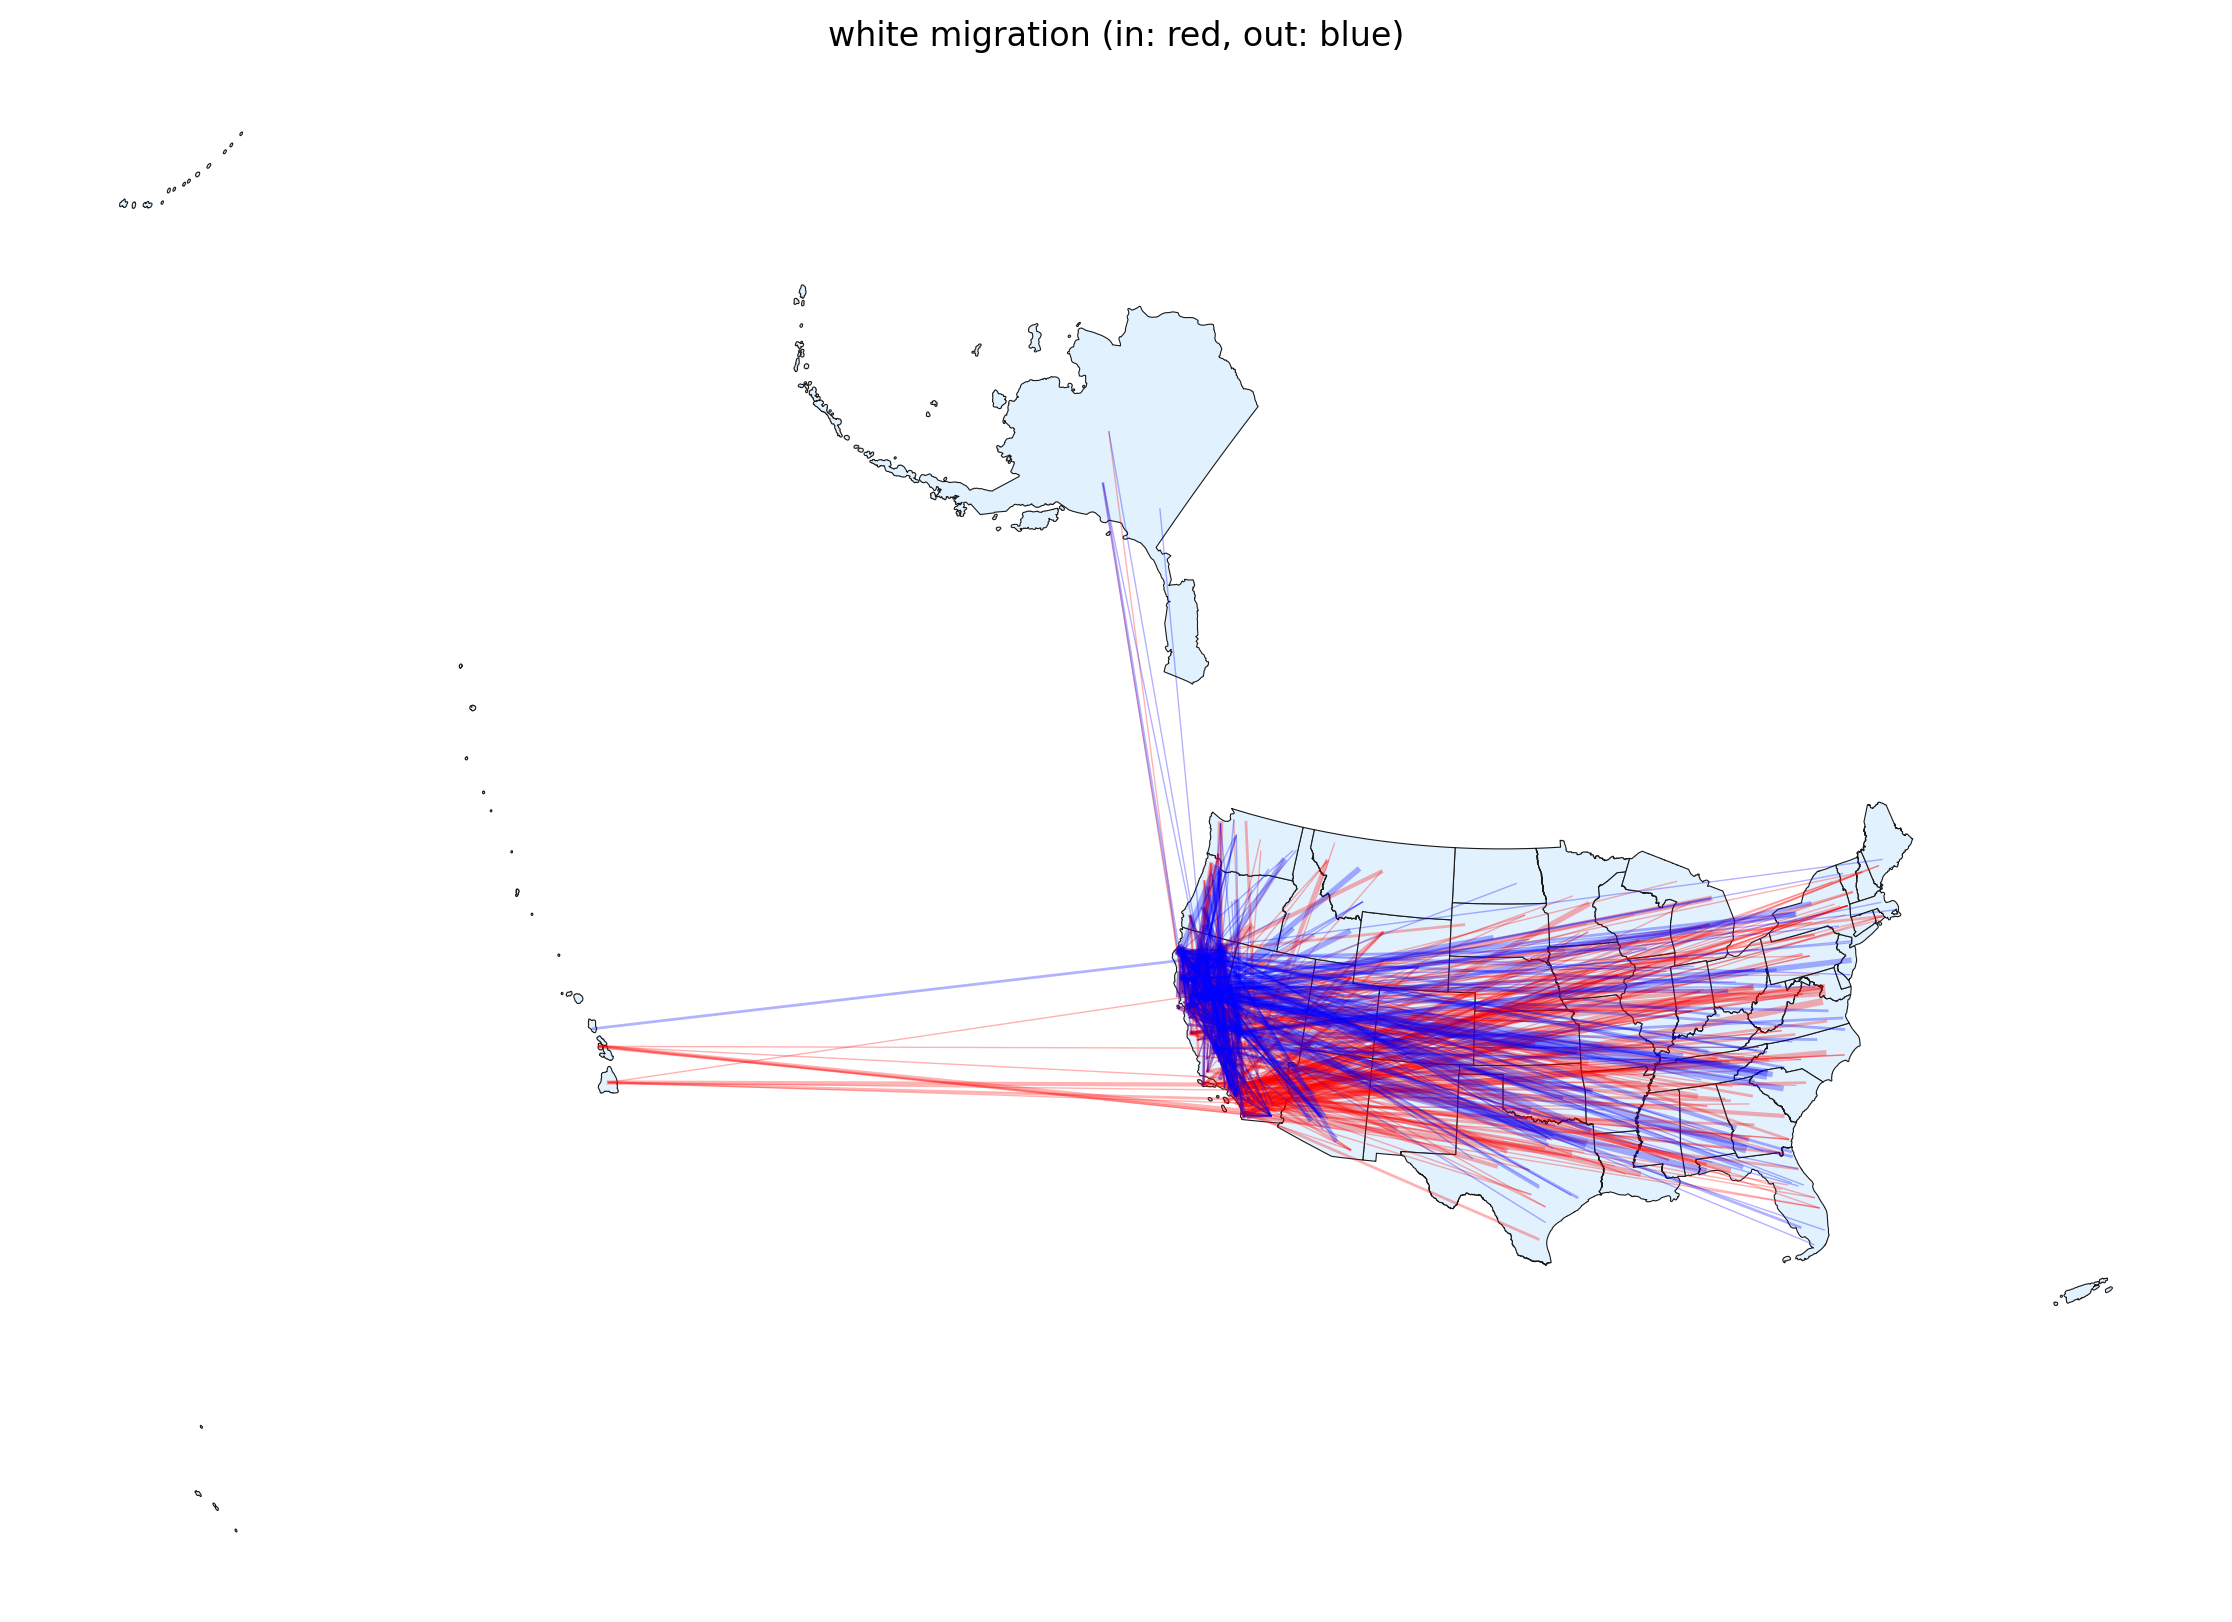

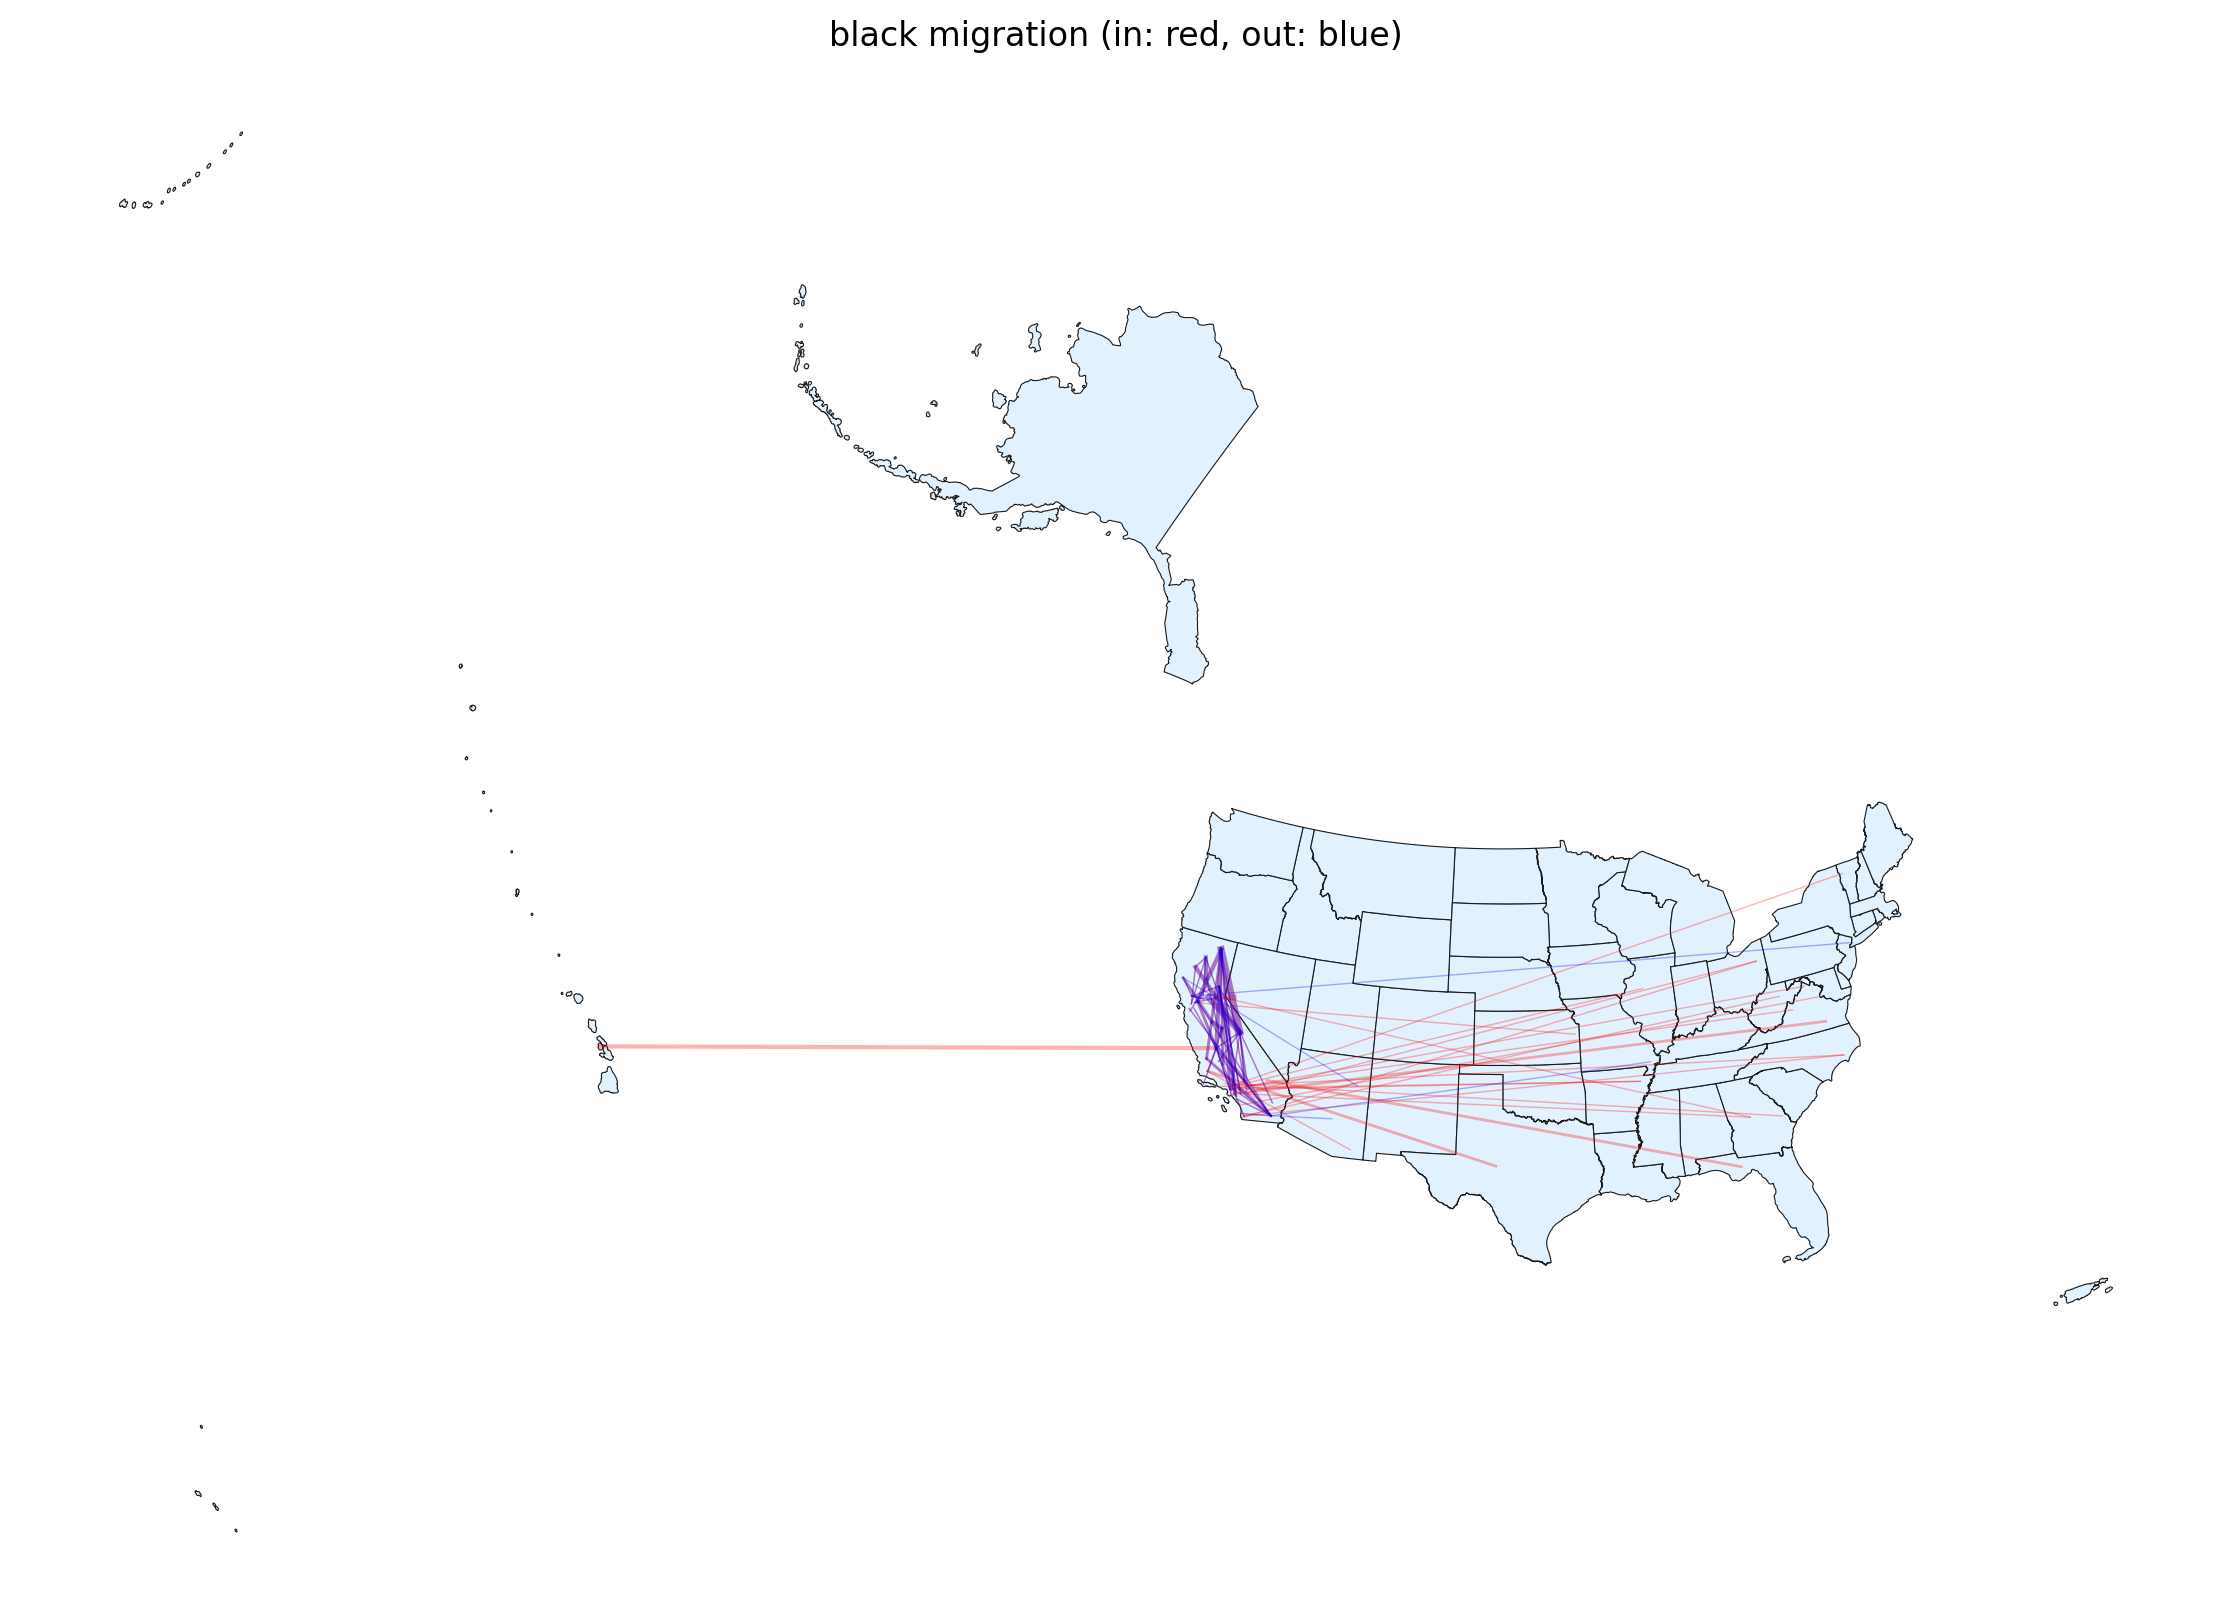

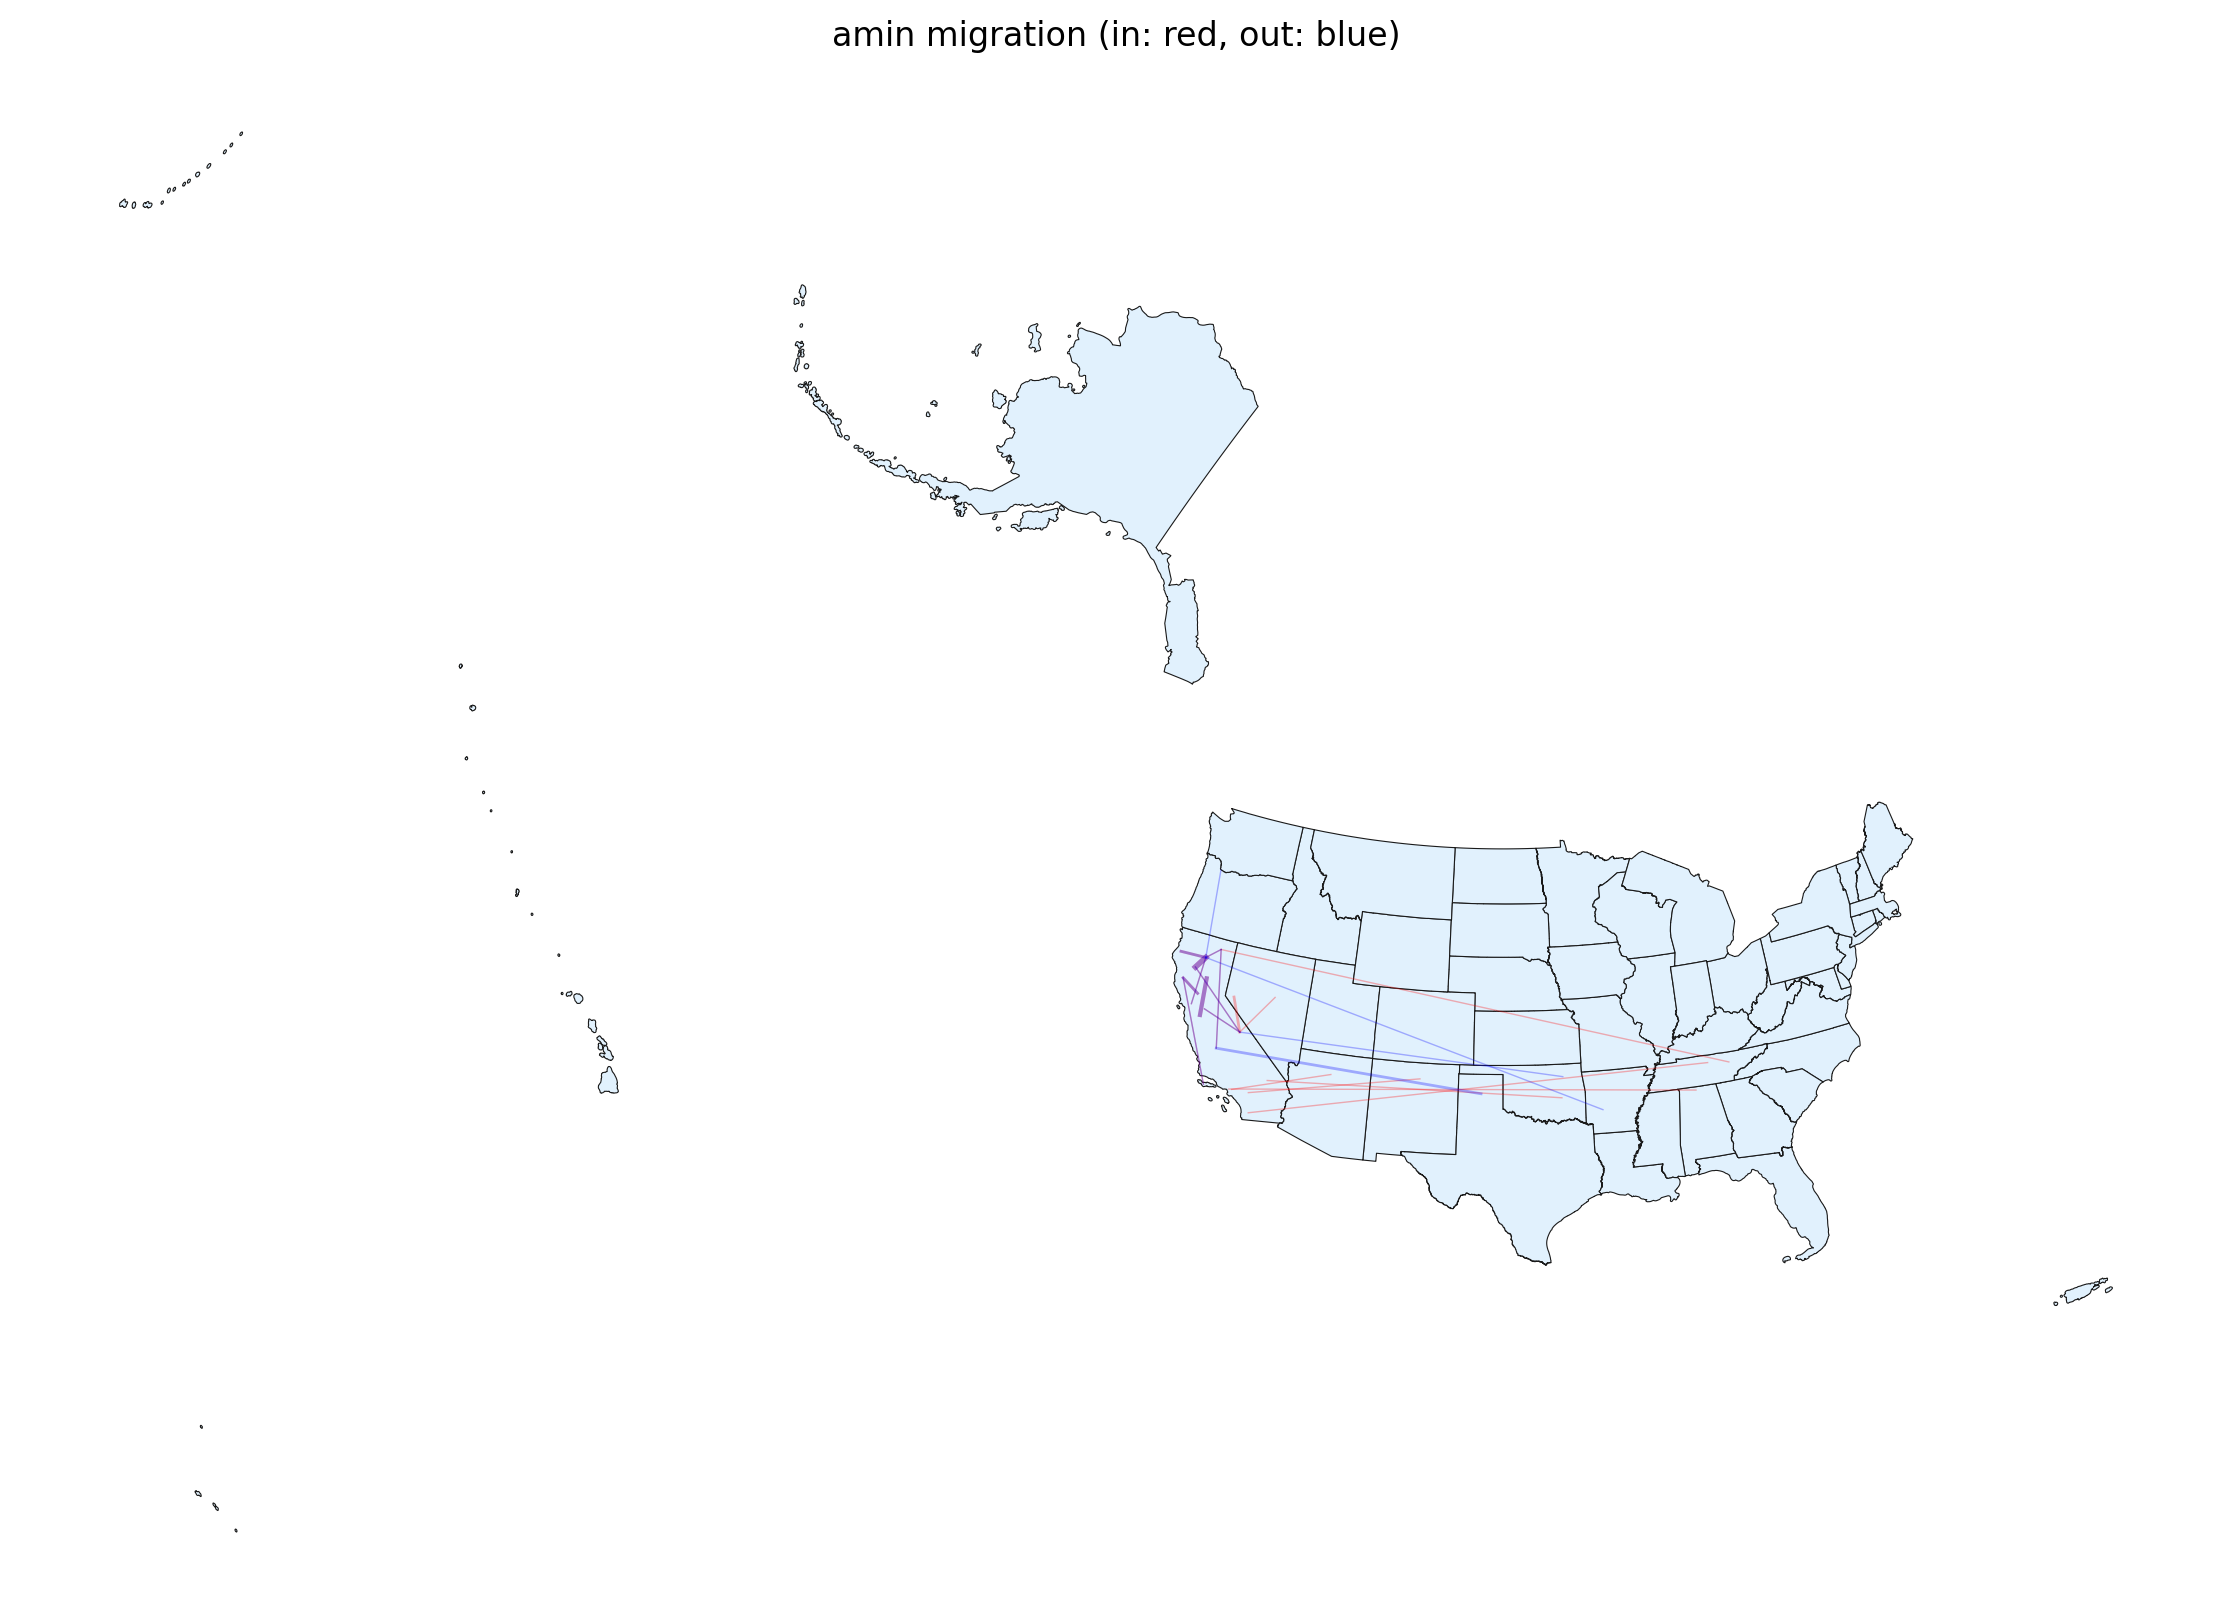

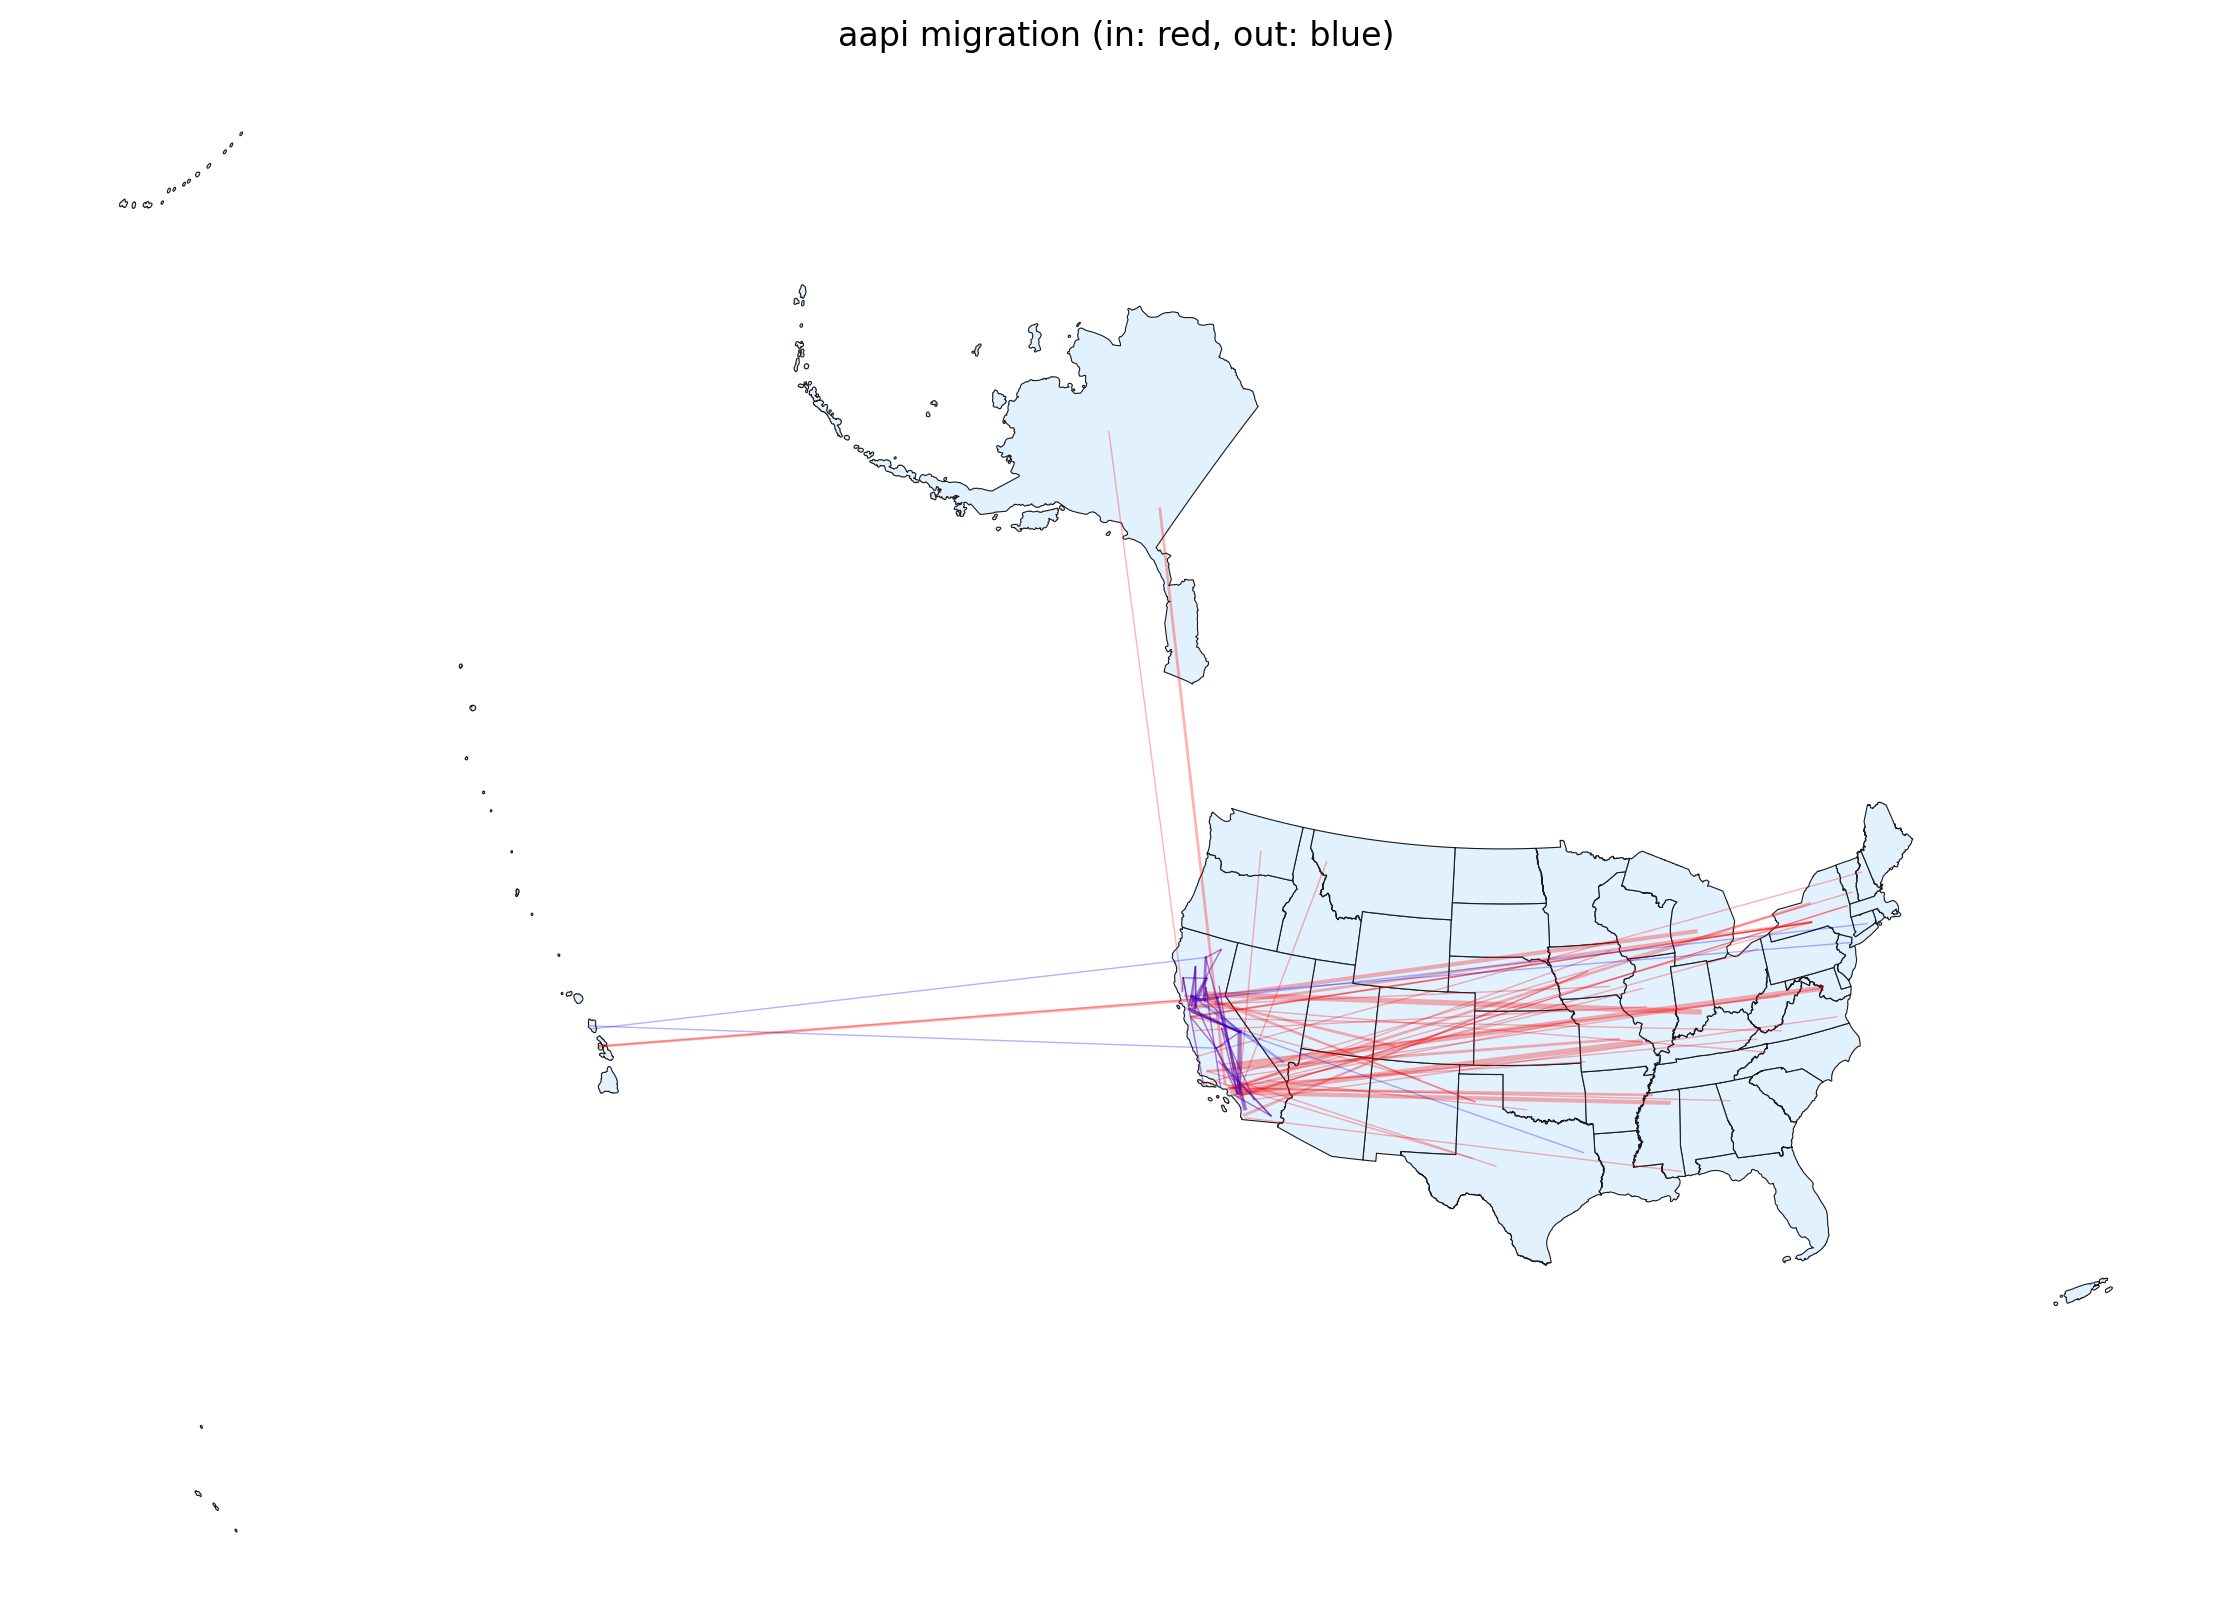

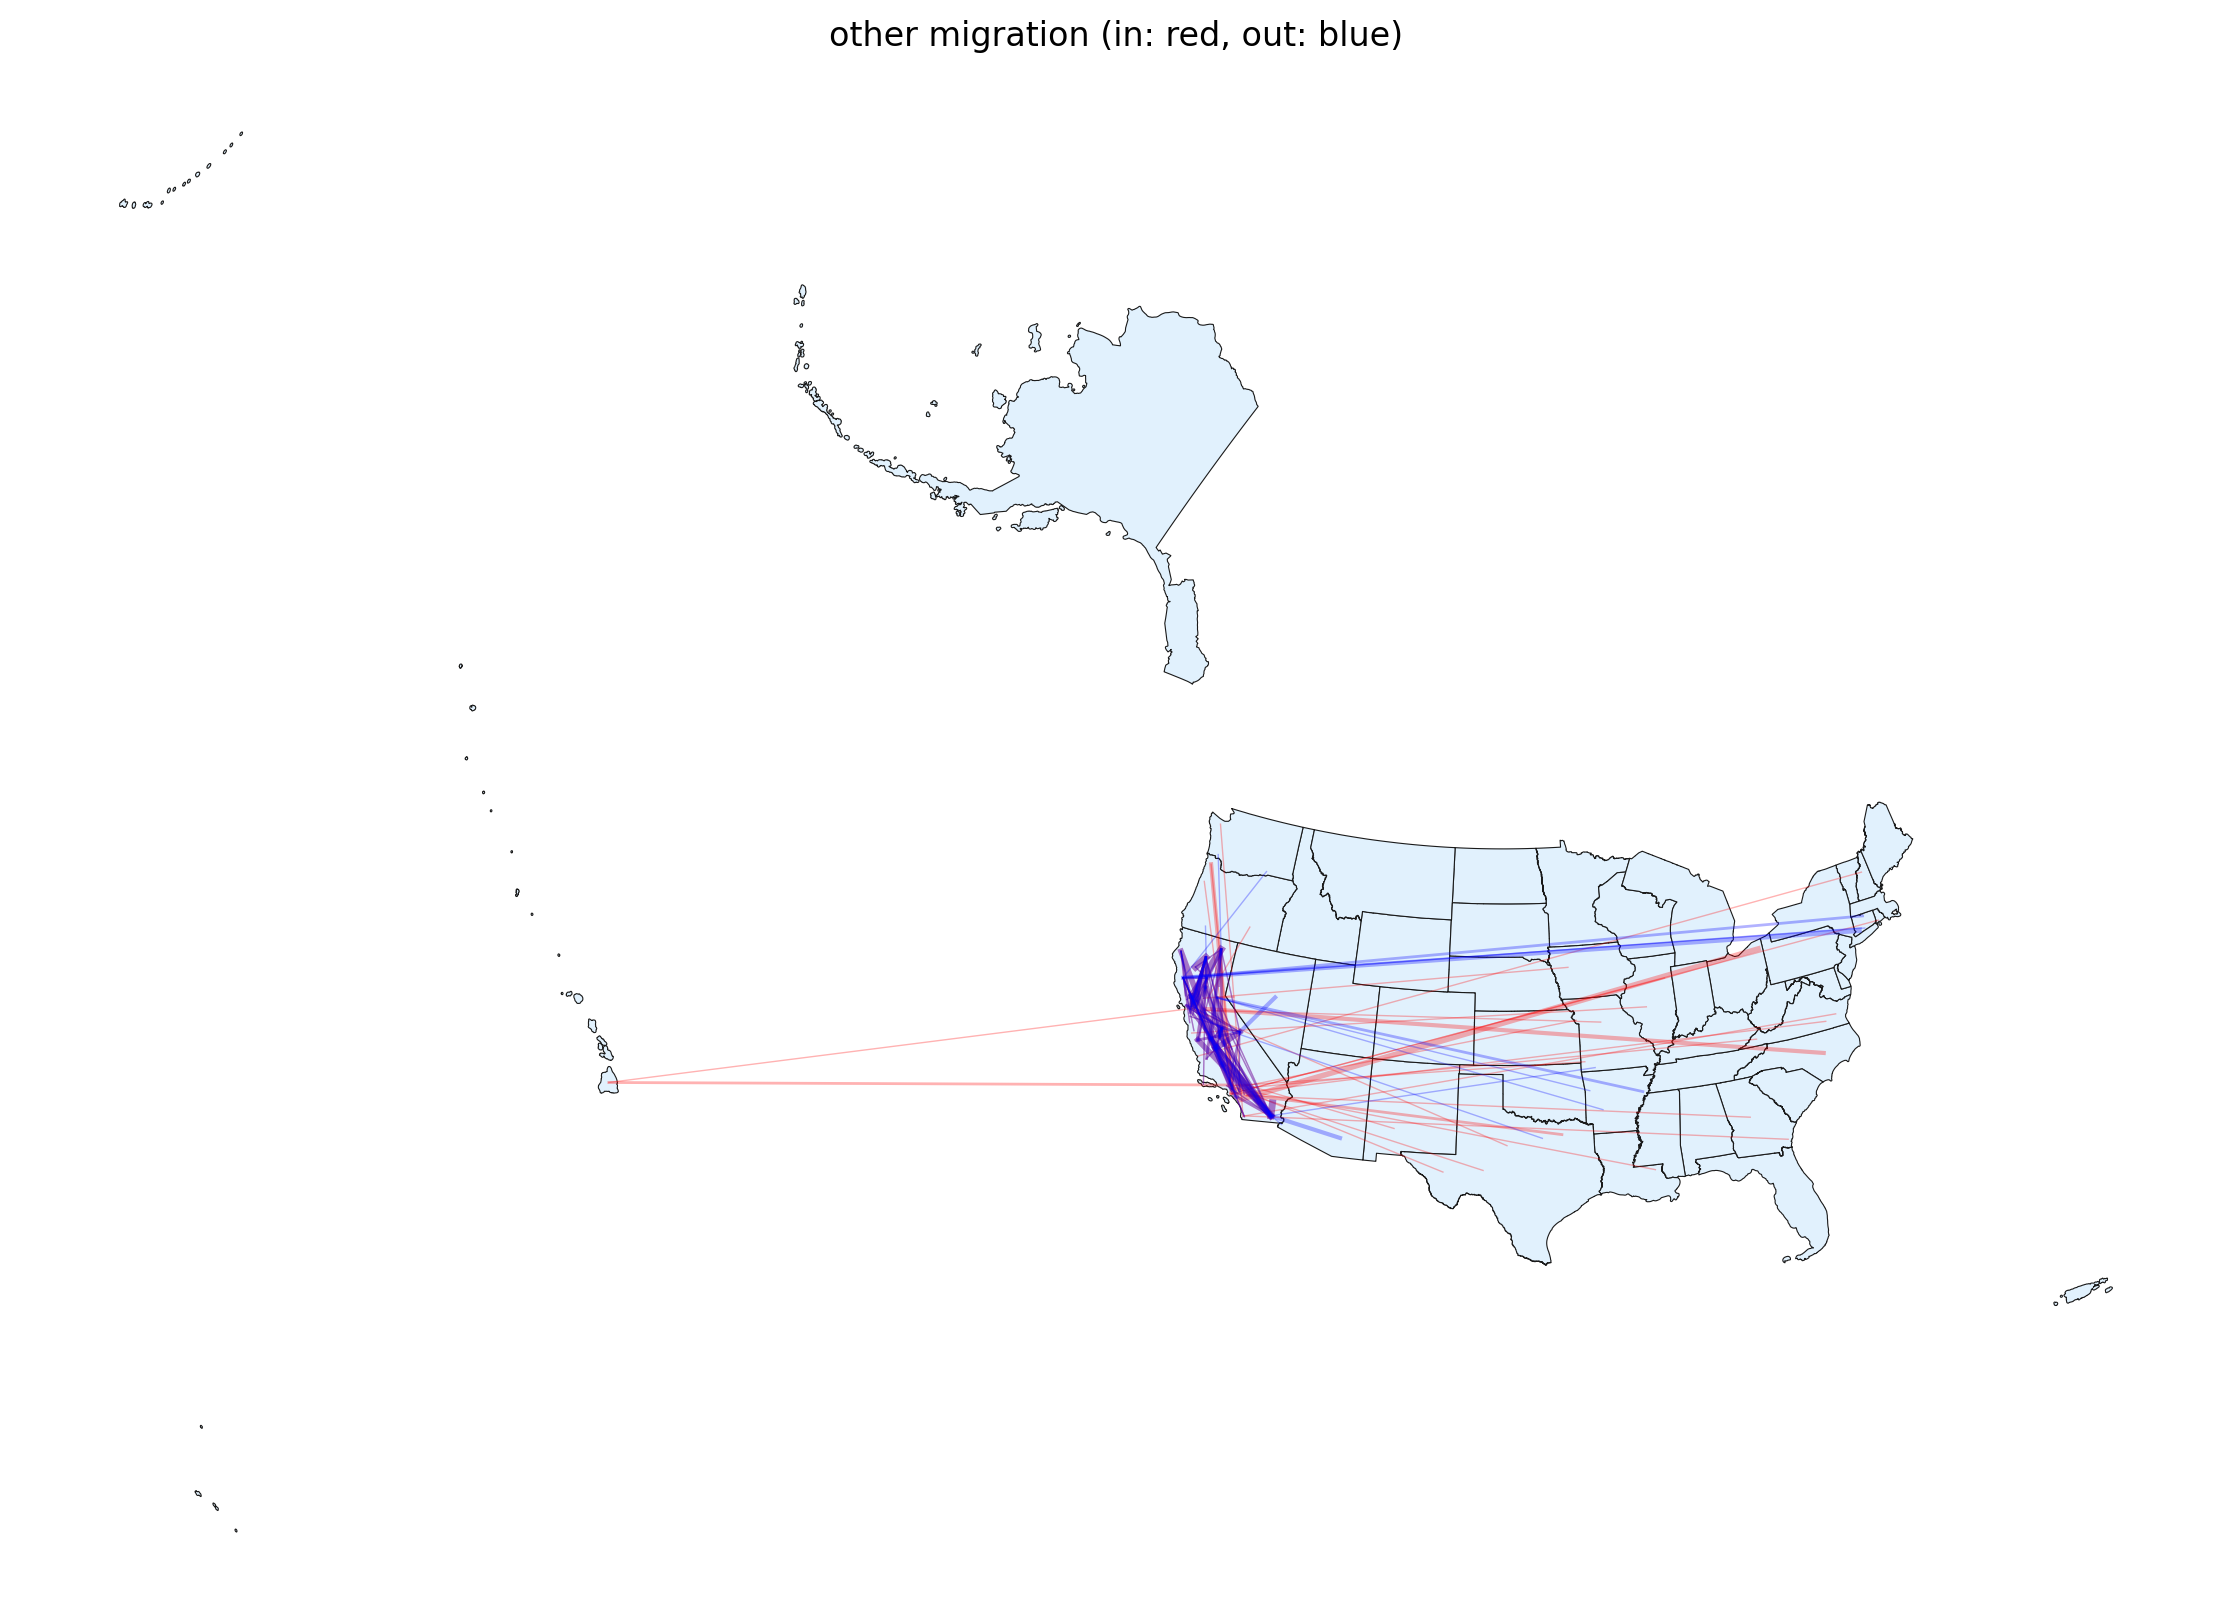

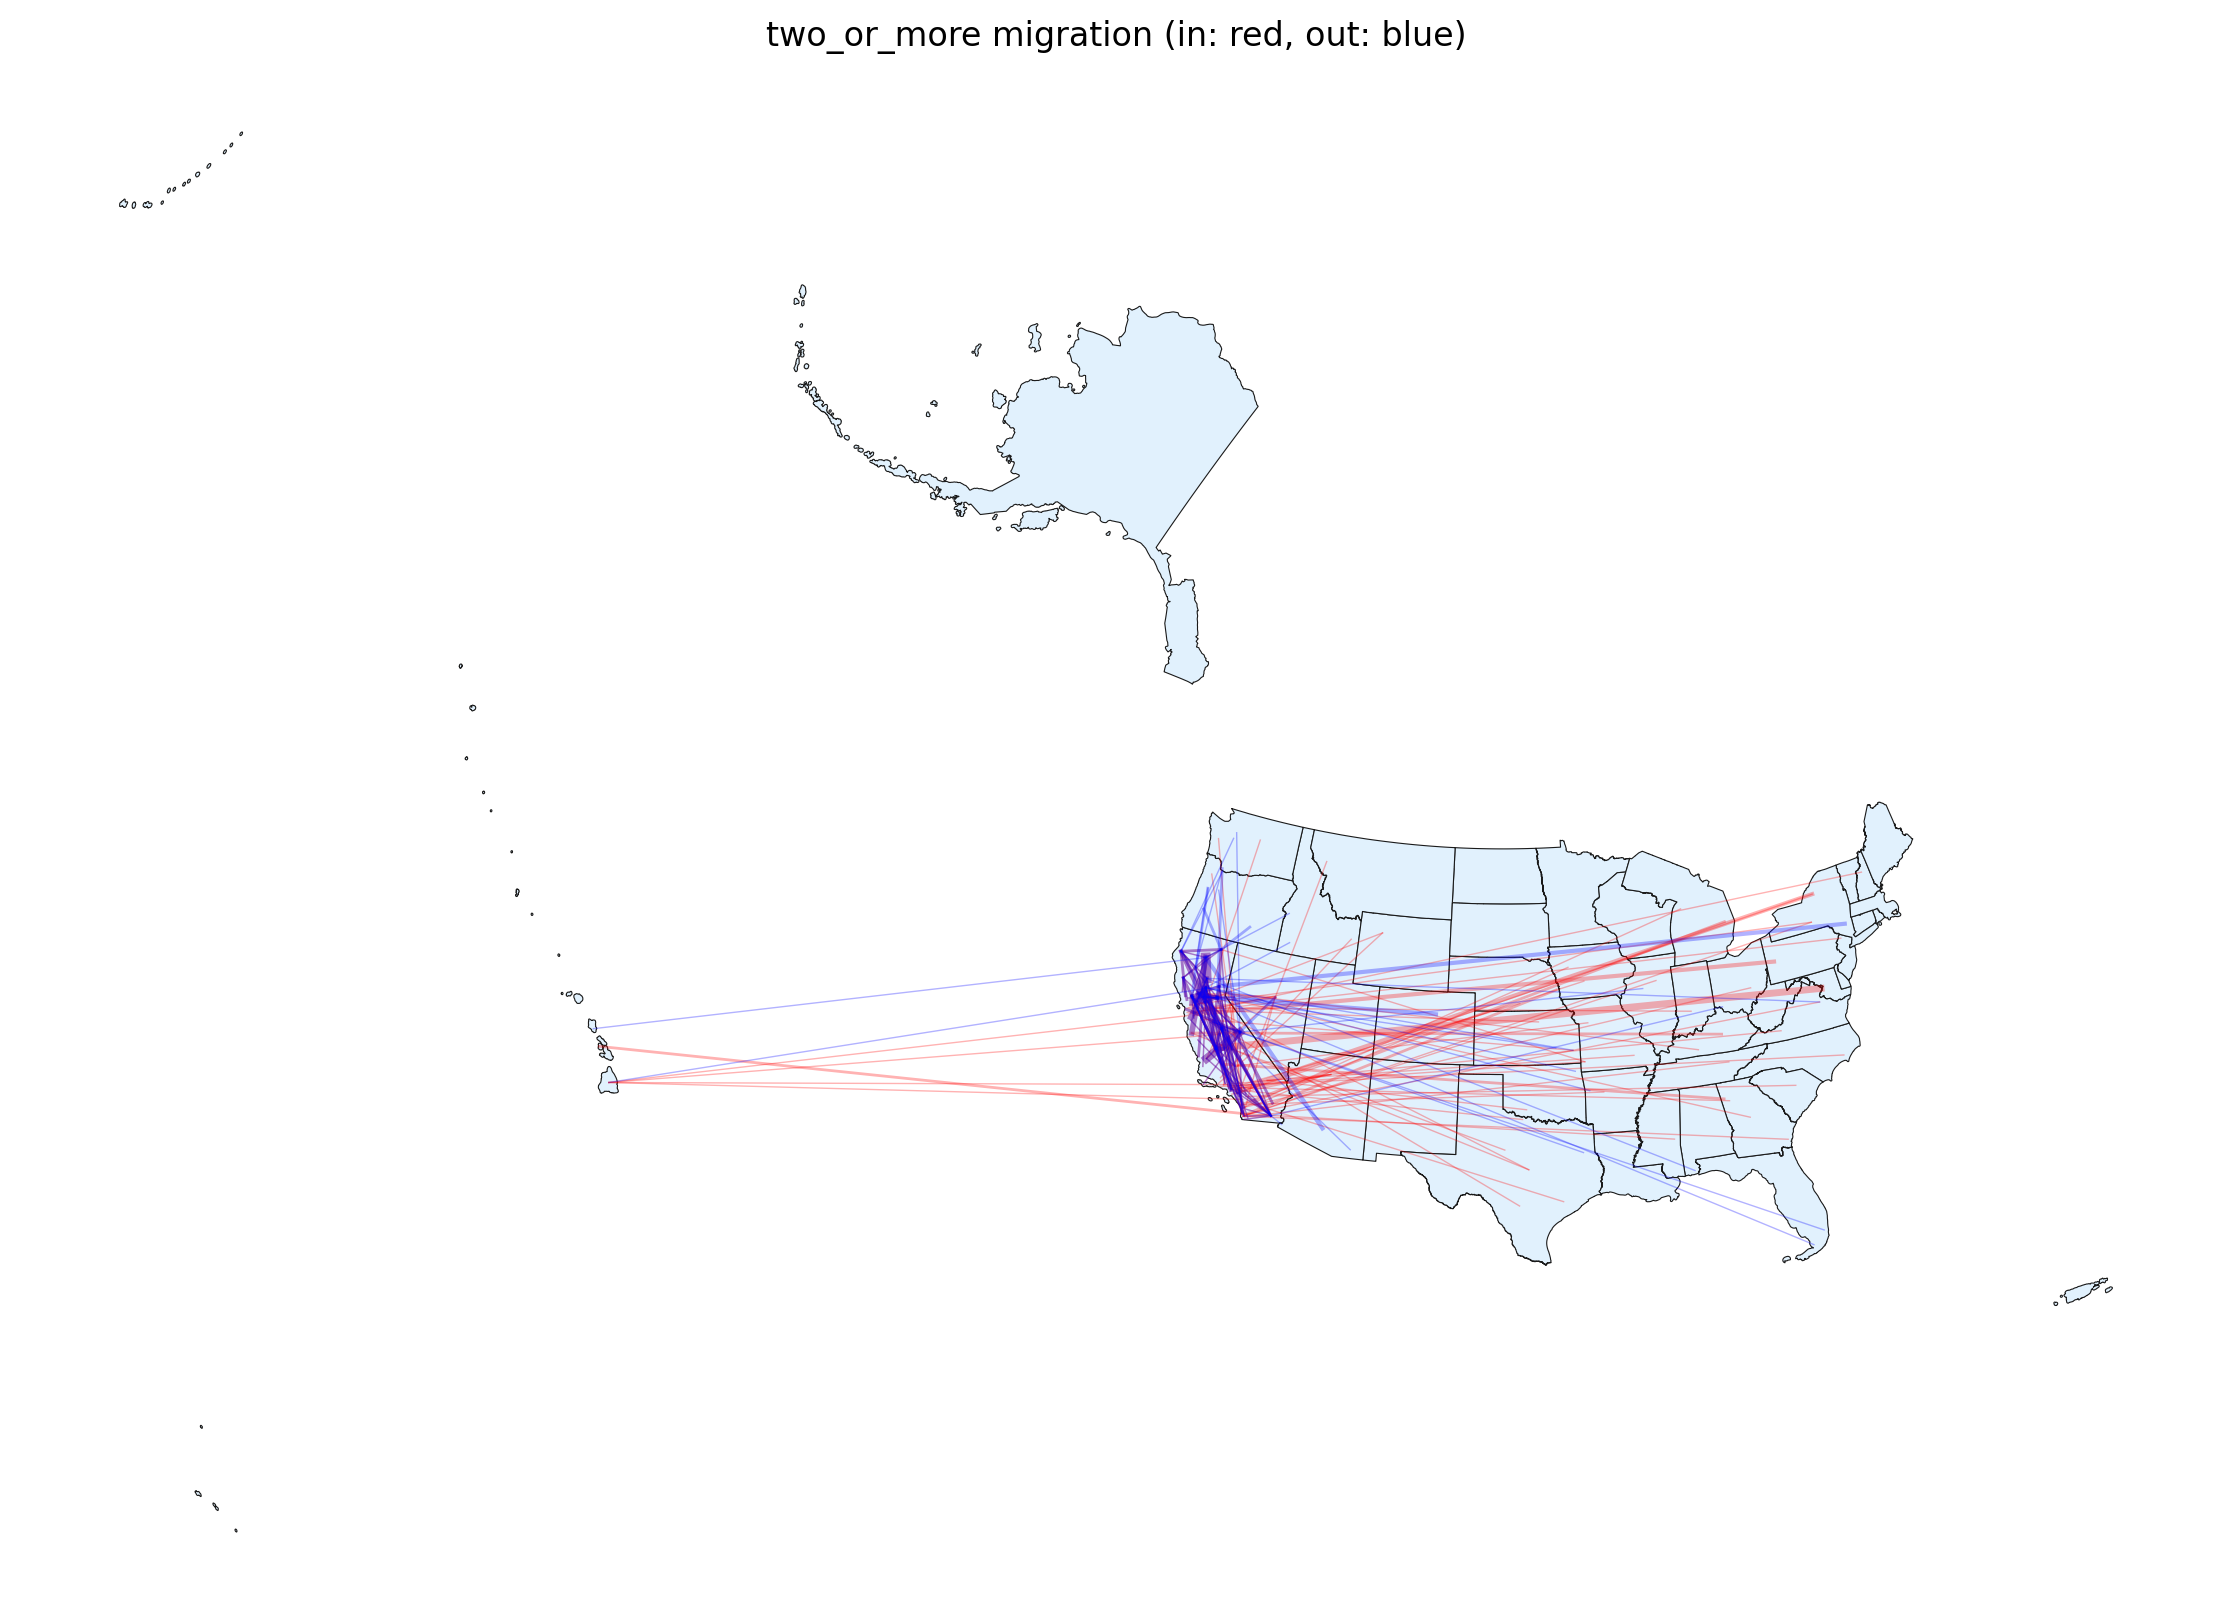

In [39]:
# @markdown We're hiding a massive code block that extracts each race category
# @markdown from the flow dataframe and makes it plottable.

for race in ['white', 'black', 'amin', 'aapi', 'other', 'two_or_more']:
    race_mask = puma_flows_df["race"] == race
    race_flows_df = puma_flows_df[race_mask]

    # Find rows where the destination ("to") is in the state we care about
    to_column = race_flows_df["to"]
    in_state_destination_mask = to_column.str.startswith(flow_state)
    in_flow_rows = race_flows_df[in_state_destination_mask]

    # Group by origin and destination, then count how many rows are in each pair
    in_flow_grouped = in_flow_rows.groupby(["from", "to"])
    in_flow_counts = in_flow_grouped.size()

    # Find rows where the origin ("from") is in the state we care about
    from_column = race_flows_df["from"]
    in_state_origin_mask = from_column.str.startswith(flow_state)
    out_flow_rows = race_flows_df[in_state_origin_mask]

    # Group by origin and destination, then count how many rows are in each pair
    out_flow_grouped = out_flow_rows.groupby(["from", "to"])
    out_flow_counts = out_flow_grouped.size()

    ax = state_gdf.plot(
        figsize=(20, 10),
        edgecolor="0.1",
        linewidth=0.4,
        color="#e1f1fd",
    )

    # Make inbound flows to be red and outbound flows blue
    flow_sets = [in_flow_counts, out_flow_counts]
    colors = ["red", "blue"]

    for i in range(len(flow_sets)):
        flow_counts = flow_sets[i]
        color = colors[i]

        for flow_pair, count in flow_counts.items():
            flow_from = flow_pair[0]
            flow_to = flow_pair[1]

            try:
                from_point = proj_puma_points[flow_from]
                to_point = proj_puma_points[flow_to]

                from_x, from_y = from_point.coords.xy
                to_x, to_y = to_point.coords.xy
            except KeyError:
                # Skip this flow if either PUMA code is missing
                continue

            line_x_values = [from_x[0], to_x[0]]
            line_y_values = [from_y[0], to_y[0]]

            ax.plot(
                line_x_values,
                line_y_values,
                color=color,
                linewidth=0.5 * count,
                alpha=0.3,
            )

    ax.axis("off")
    ax.set_title(f"{race} migration (in: red, out: blue)")
    plt.show()


## Advanced flow visualizations with FlowmapBlue

Now we'll use a very cool package called FlowmapBlue to create beautiful and interactive flowmaps.

This line will pop up a dialog asking for permission to generate Google Sheets credentials using your Google login. If you're doing this in Colab, it is hopefully seamless.  🤞

In [40]:
sheet_creds = google_sheets_credentials()

### ACS + FlowmapBlue

In [41]:
county_flowmap_locations_df = county_gdf[["NAMELSAD", "INTPTLON", "INTPTLAT"]]
county_flowmap_locations_df = county_flowmap_locations_df.reset_index()
county_flowmap_locations_df = county_flowmap_locations_df.rename(
    columns={"NAMELSAD": "name", "INTPTLON": "lon", "INTPTLAT": "lat", "GEOID": "id"}
)
county_flowmap_locations_df

,id,name,lon,lat
0,31039,Cuming County,-096.7885168,+41.9158651
1,53069,Wahkiakum County,-123.4244583,+46.2946377
2,35011,De Baca County,-104.3686961,+34.3592729
3,31109,Lancaster County,-096.6886584,+40.7835474
4,31129,Nuckolls County,-098.0468422,+40.1764918
...,...,...,...,...
3229,13123,Gilmer County,-084.4546244,+34.6905055
3230,27135,Roseau County,-095.8215042,+48.7610683
3231,28089,Madison County,-090.0341603,+32.6343703
3232,48227,Howard County,-101.4387208,+32.3034298


In [42]:
a_to_b_acs_flow_counts = flow_df.reset_index()[["a_fips", "b_fips", "a_to_b_flow_est"]]
a_to_b_acs_flow_counts = a_to_b_acs_flow_counts.rename(
    columns={"a_fips": "origin", "b_fips": "dest", "a_to_b_flow_est": "count"}
)


b_to_a_acs_flow_counts = flow_df.reset_index()[["a_fips", "b_fips", "b_to_a_flow_est"]]
b_to_a_acs_flow_counts = b_to_a_acs_flow_counts.rename(
    columns={"b_fips": "origin", "a_fips": "dest", "b_to_a_flow_est": "count"}
)


# pd.concat takes to dataframes with the same columns (here, we have
# ["origin", "dest", "count"]) and stacks them to create a unified dataframe
acs_flow_counts = pd.concat([a_to_b_acs_flow_counts, b_to_a_acs_flow_counts])

Making the flow sheet takes 1-2 minutes.

In [43]:
acs_flow_sheet = generate_flow_sheet(
    sheet_creds=sheet_creds,
    locations_df=county_flowmap_locations_df.sort_values(by=["id"]),
    sheet_title="DATA 20195: ACS migration flows",
    flow_title="U.S. Census ACS county-to-county migration flows, 2016-2020",
    incoming_tooltip="People in",
    outgoing_tooltip="People out",
    flow_tooltip="People",
    total_unit="people",
    data_source_name="U.S. Census ACS county-to-county migration flows, 2016-2020",
    data_source_url="https://www.census.gov/programs-surveys/acs",
    flows={"2016-2020": acs_flow_counts},
)

100%|██████████| 1/1 [00:48<00:00, 48.37s/it]


A flow sheet is just a spreadsheet with specially labeled tabs. If you click on the link below, you should see that the `acs_flow_counts` dataframe has been stored in the "2016-2020" tab.

In [44]:
print(acs_flow_sheet.url)

https://docs.google.com/spreadsheets/d/1gVUjg_8XbKbWD24EiP_sr2s6URKPAaSMzrng43kXNzQ


Now we print out a url for the FlowmapBlue map. Clicking on this url will redirect you to a website that visualizes the data contained in flowsheet above.

In [45]:
print(f"https://www.flowmap.blue/{acs_flow_sheet.url.split('/')[-1]}")

https://www.flowmap.blue/1gVUjg_8XbKbWD24EiP_sr2s6URKPAaSMzrng43kXNzQ


#### Aggregating up to the state level

In [46]:
state_flowmap_locations_df = state_gdf[["NAME", "INTPTLON", "INTPTLAT"]]
state_flowmap_locations_df = state_flowmap_locations_df.reset_index()
state_flowmap_locations_df = state_flowmap_locations_df.rename(
    columns={"NAME": "name", "INTPTLON": "lon", "INTPTLAT": "lat", "GEOID": "id"}
)

In [47]:
state_acs_flow_counts = acs_flow_counts.copy()
state_acs_flow_counts["origin"] = state_acs_flow_counts["origin"].str[:2]
state_acs_flow_counts["dest"] = state_acs_flow_counts["dest"].str[:2]
state_acs_flow_counts = state_acs_flow_counts.groupby(by=["origin", "dest"]).sum().reset_index()

# Exclude intra-state flows.
state_acs_flow_counts = state_acs_flow_counts[
    state_acs_flow_counts["origin"] != state_acs_flow_counts["dest"]
]
state_acs_flow_counts

,origin,dest,count
1,01,02,1366
2,01,04,3034
3,01,05,2058
4,01,06,7050
5,01,08,5594
...,...,...,...
2697,72,51,3452
2698,72,53,1228
2699,72,54,338
2700,72,55,2926


In [48]:
state_acs_flow_sheet = generate_flow_sheet(
    sheet_creds=sheet_creds,
    locations_df=state_flowmap_locations_df,
    sheet_title="DATA 20195: ACS migration flows (interstate)",
    flow_title="U.S. Census ACS interstate migration flows, 2016-2020",
    incoming_tooltip="People in",
    outgoing_tooltip="People out",
    flow_tooltip="People",
    total_unit="people",
    data_source_name="U.S. Census ACS state-to-state migration flows, 2016-2020",
    data_source_url="https://www.census.gov/programs-surveys/acs",
    flows={"2016-2020": state_acs_flow_counts},
)

100%|██████████| 1/1 [00:02<00:00,  2.15s/it]


In [49]:
print(state_acs_flow_sheet.url)
print(f"https://www.flowmap.blue/{state_acs_flow_sheet.url.split('/')[-1]}")

https://docs.google.com/spreadsheets/d/1KXFILhDgw5CUDkEZQo-cwQc4y2abRbiIXwbdW0Wyf50
https://www.flowmap.blue/1KXFILhDgw5CUDkEZQo-cwQc4y2abRbiIXwbdW0Wyf50


There's probably not any time left in lab by the time you get here!  But later on, you can mess around with the data sliced by race.

### PUMS + FlowmapBlue


In [50]:
migpuma_by_puma_df = pd.read_excel("https://usa.ipums.org/usa/resources/volii/puma_migpuma1_pwpuma00_2020.xls", dtype=str)

migpuma_by_puma_df["puma_geoid"] = (
    migpuma_by_puma_df["State of Residence (ST)"]
    + migpuma_by_puma_df["PUMA"]
)

migpuma_by_puma_df["migpuma_geoid"] = (
    migpuma_by_puma_df["Place of Work State (PWSTATE2) or Migration State (MIGPLAC1)"]
    + migpuma_by_puma_df["PWPUMA00 or MIGPUMA1"]
).str[1:]

migpuma_by_puma_df = migpuma_by_puma_df[["puma_geoid", "migpuma_geoid"]].set_index("migpuma_geoid").sort_values(by="puma_geoid")

In [51]:
exclude_migpumas = {"7200002", "1100100"}
exclude_pumas = {"1100101"}

In [52]:
puma_flowmap_locations_df = puma_points_gdf.drop(columns=["geometry"])
puma_flowmap_locations_df.index.names = ["id"]
puma_flowmap_locations_df

,name,lat,lon
id,,,
0101700,"Autauga, Dallas, Lowndes & Perry Counties PUMA",32.405885,-86.946190
0100100,"Lauderdale, Colbert & Franklin Counties PUMA",34.696105,-87.775013
0100200,Limestone County PUMA,34.810239,-86.981399
0101000,"Cullman, Marion & Winston Counties PUMA",34.128017,-87.360304
0102400,Coffee & Dale Counties PUMA,31.416840,-85.813651
...,...,...,...
5600100,"Sheridan, Park, Teton, Lincoln & Big Horn Coun...",43.964580,-109.298071
5600200,"Campbell, Goshen, Platte, Johnson, Washakie, W...",43.651810,-105.427053
5600300,Laramie County PUMA,41.292830,-104.660395


In [53]:
# For the purposes of visualization, arbitrarily assign ambiguous MIGPUMAs to the
# first corresponding PUMA (in lexicographic order).
missing_migpumas = (set(puma_flows_df["from"]) | set(puma_flows_df["to"])) - set(proj_puma_points)
migpuma_rows = []

for missing_migpuma in missing_migpumas - exclude_migpumas:
    puma_geoid = migpuma_by_puma_df.loc[[missing_migpuma]].iloc[0]["puma_geoid"]
    if puma_geoid in exclude_pumas:
        continue

    migpuma_rows.append({
        "id": missing_migpuma,
        **puma_flowmap_locations_df.loc[puma_geoid],
    })

puma_flowmap_locations_df = pd.concat([
    puma_flowmap_locations_df,
    pd.DataFrame(migpuma_rows).set_index("id"),
])

In [54]:
filtered_puma_flows_df = puma_flows_df[
    ~puma_flows_df["from"].isin(exclude_migpumas)
    & ~puma_flows_df["to"].isin(exclude_pumas)
]

In [55]:
display_names = {
    "white": "White",
    "black": "Black or African American",
    "amin": "American Indian or Alaska Native",
    "aapi": "Asian; Native Hawaiian or Other Pacific Islander",
    "other": "Some Other Race",
    "two_or_more": "Two or More Races",
}

In [56]:
puma_flows_df

,from,to,race
22,1301300,0100700,two_or_more
23,0100490,0100402,black
24,0100490,0100402,black
25,0100490,0100402,black
36,0100490,0101404,white
...,...,...,...
3399053,5326300,5600200,white
3399054,5326300,5600200,white
3399055,5326300,5600200,white
3399056,3000600,5600200,white


In [57]:
flows_by_race = {}

for race in filtered_puma_flows_df["race"].unique():
    race_flows_df = filtered_puma_flows_df[filtered_puma_flows_df["race"] == race].groupby(
        by=["from", "to"]
    ).size()
    flows_by_race[display_names[race]] = race_flows_df.reset_index().rename(
        columns={"from": "origin", "to": "dest", 0: "count"}
    )

In [58]:
flow_by_race_sheet = generate_flow_sheet(
    sheet_creds=sheet_creds,
    locations_df=puma_flowmap_locations_df.reset_index(),
    sheet_title="DATA 20195: PUMS migration flows",
    flow_title="U.S. Census PUMS migration flows, 2023",
    incoming_tooltip="People in",
    outgoing_tooltip="People out",
    flow_tooltip="People",
    total_unit="people",
    data_source_name="U.S. Census PUMS migration flows, 2023",
    data_source_url="https://www.census.gov/programs-surveys/acs/microdata.html",
    flows=flows_by_race,
)

100%|██████████| 6/6 [00:24<00:00,  4.16s/it]


In [59]:
print(flow_by_race_sheet.url)

https://docs.google.com/spreadsheets/d/1zGn-yykE3H_CX1TTZqSzRfZoMU-ov5CcHwi7kgo0RAA


In [60]:
print(f"https://www.flowmap.blue/{flow_by_race_sheet.url.split('/')[-1]}")

https://www.flowmap.blue/1zGn-yykE3H_CX1TTZqSzRfZoMU-ov5CcHwi7kgo0RAA


# Homework 4

First, the warmup.  Create a copy of `filtered_puma_flows_df` with a new column called `from_state_fips` that contains the first two characters of the `from` column (which is the sending state!).  Use string slicing to do this.  Likewise, create `to_state_fips`. Using this, estimate how many counties in New York State had a positive flow of American Indian/Native American people to Oklahoma in 2023?  Briefly explain how you figured it out.

Then, the main event:  use the ACS migration matrix or the PUMS resources to drill down to an interesting question.  Explain how you are using the methods here to suggest the question and approach answering it.  Create a data product that addresses your question.



**Reading question**:  Our migration reading is by Enrico Moretti, writing about "The Inequality of Mobility and Cost of Living."  His chapter has many claims about how education policy, employment policy, and housing policy influence (and are influenced by) human migration within the U.S.  Choose one claim from the chapter (please include a direct quote), and explain how you could use geospatial data to investigate Moretti's argument.  